# NCWP Evaluation Notebook

This notebook runs the NCWP (PCA-whitening) evaluation using the trained decoder-only base model.

Steps:
- Configure paths and parameters
- Load corpus and base model weights
- Run NCWP evaluation over target dimensions
- Save comparison CSV and plot mAP vs dimension

All modules are imported from the local project folders.
docker build -t make-embedding .

In [1]:
# Environment and paths
import os
import sys
import torch
import pandas as pd
import numpy as np

# Add project root (../) so local packages can be imported
ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

print("Project root:", ROOT)
print("Python:", sys.version.split()[0])
print("CUDA available:", torch.cuda.is_available())


Project root: /home/workspace/Make_embedding/NCWP
Python: 3.11.10
CUDA available: True


In [ ]:
# Parameters
CORPUS = os.path.join(ROOT, "labeled_corpus1000.csv")  # recommended (embedding-based labels)

# Evaluate only these tokenizer subdirs (exclude ws)
TOKS = ["bpe", "wordpiece"]
WEIGHTS_BASE_DIR = os.path.join(ROOT, "weights")

OUT_DIR = os.path.join(os.getcwd(), "results")  # saved here
BASE_DIM = 512
DIMS = [2, 4, 8, 16, 32, 64, 128, 256]
PREFER_CUDA = True

os.makedirs(OUT_DIR, exist_ok=True)
print("CORPUS:", CORPUS)
print("TOKS:", TOKS)
print("WEIGHTS_BASE_DIR:", WEIGHTS_BASE_DIR)
print("OUT_DIR:", OUT_DIR)
print("BASE_DIM:", BASE_DIM)
print("DIMS:", DIMS)


CORPUS: /home/workspace/Make_embedding/NCWP/labeled_corpus1000.csv
TOKS: ['bpe', 'wordpiece']
WEIGHTS_BASE_DIR: /home/workspace/Make_embedding/NCWP/weights
OUT_DIR: /home/workspace/Make_embedding/NCWP/ncwp_eval/results
BASE_DIM: 512
DIMS: [4, 8, 16, 32, 64, 128, 256]


In [3]:
# Imports from local packages
from ncwp_eval.code.eval import run_ncwp_evaluation
from ncwp_eval.code.graphs import plot_metrics_vs_dim, plot_per_label_maps, plot_per_label_panels


In [4]:
# Select device
device = "cuda" if (PREFER_CUDA and torch.cuda.is_available()) else "cpu"
print("device:", device)


device: cuda


In [5]:
# Run NCWP evaluation for each tokenizer (bpe, wordpiece)
dfs = {}
for tok in TOKS:
    weights_dir = os.path.join(WEIGHTS_BASE_DIR, tok)
    out_dir_tok = os.path.join(OUT_DIR, tok)
    os.makedirs(out_dir_tok, exist_ok=True)
    print(f"[Eval] tok={tok} weights_dir={weights_dir}")
    df = run_ncwp_evaluation(
        corpus_csv=CORPUS,
        weights_dir=weights_dir,
        base_dim=BASE_DIM,
        dims=DIMS,
        device=device,
        block_size=64,
    )
    dfs[tok] = df
    print("Rows:", len(df))
list(dfs.keys())


[Eval] tok=bpe weights_dir=/home/workspace/Make_embedding/NCWP/weights/bpe


/home/workspace/Make_embedding/NCWP/ncwp_eval/code/eval.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weight_path, map_location=device)


Rows: 22
[Eval] tok=wordpiece weights_dir=/home/workspace/Make_embedding/NCWP/weights/wordpiece


/home/workspace/Make_embedding/NCWP/ncwp_eval/code/eval.py:80: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(weight_path, map_location=device)


Rows: 22


['bpe', 'wordpiece']

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/bpe/comparison.csv
Saved plot: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/bpe/map_vs_dim.png


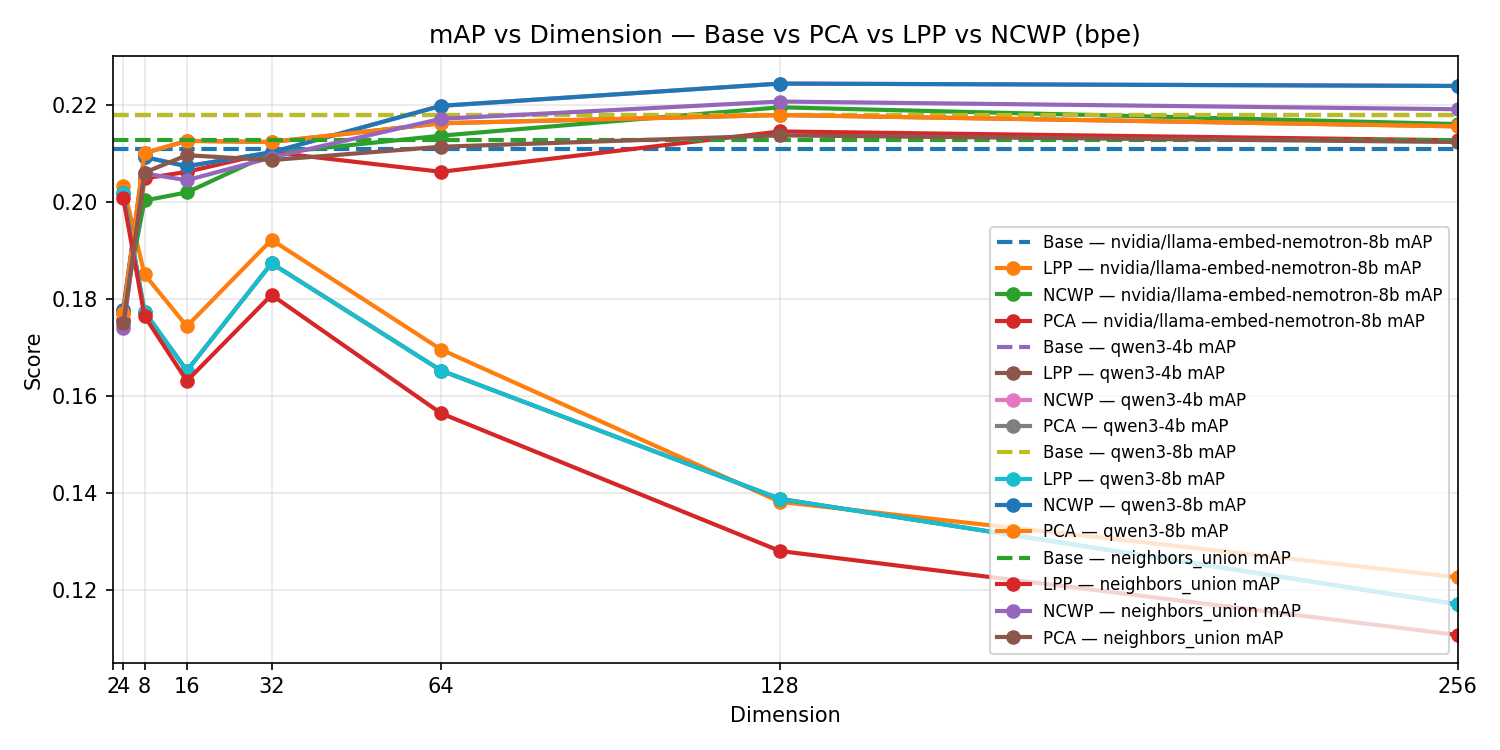

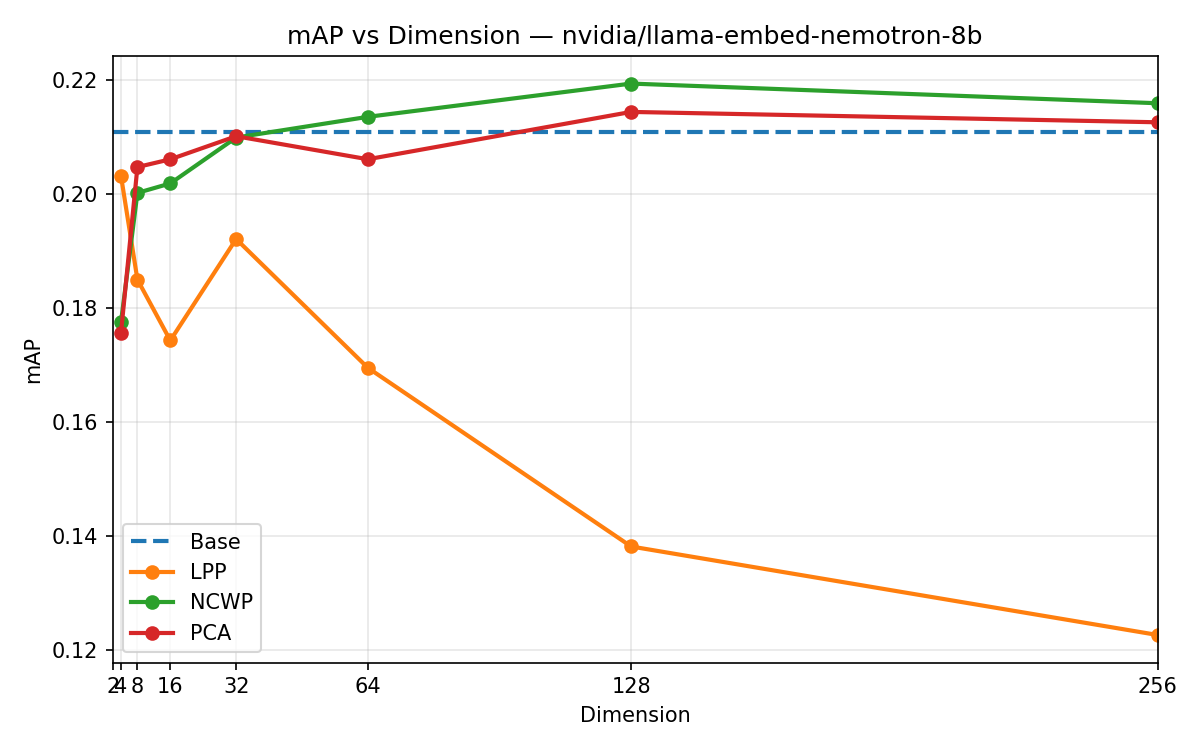

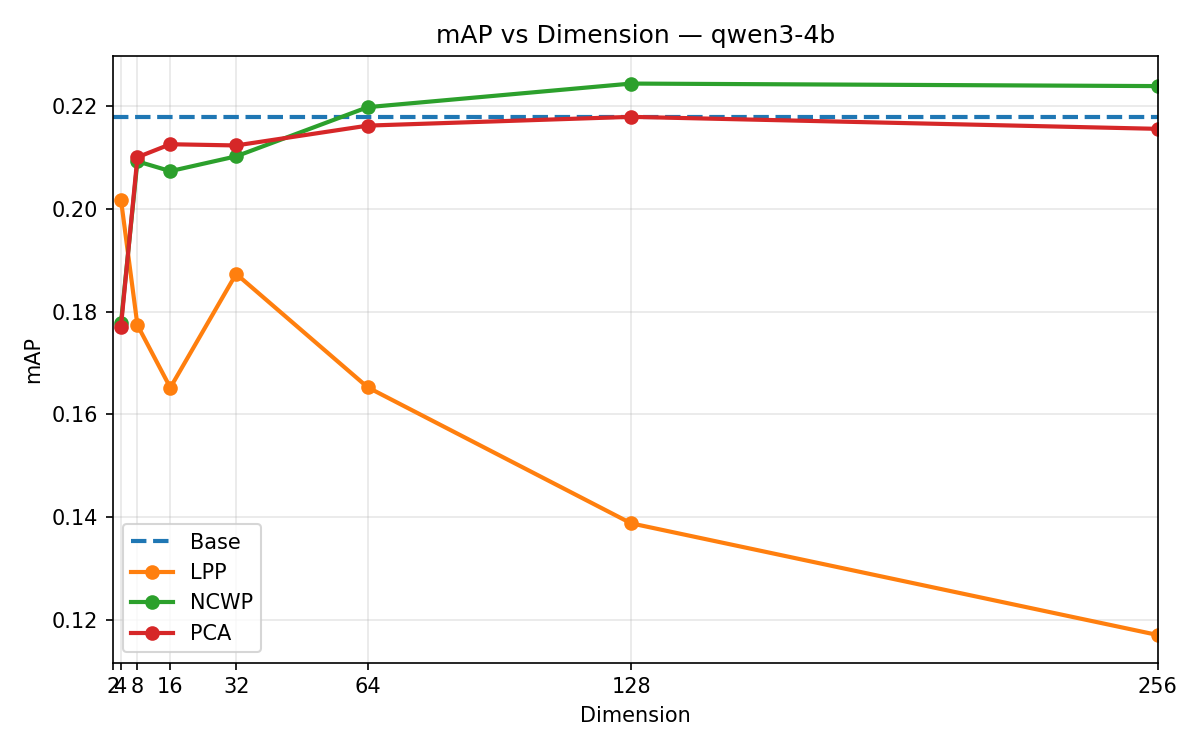

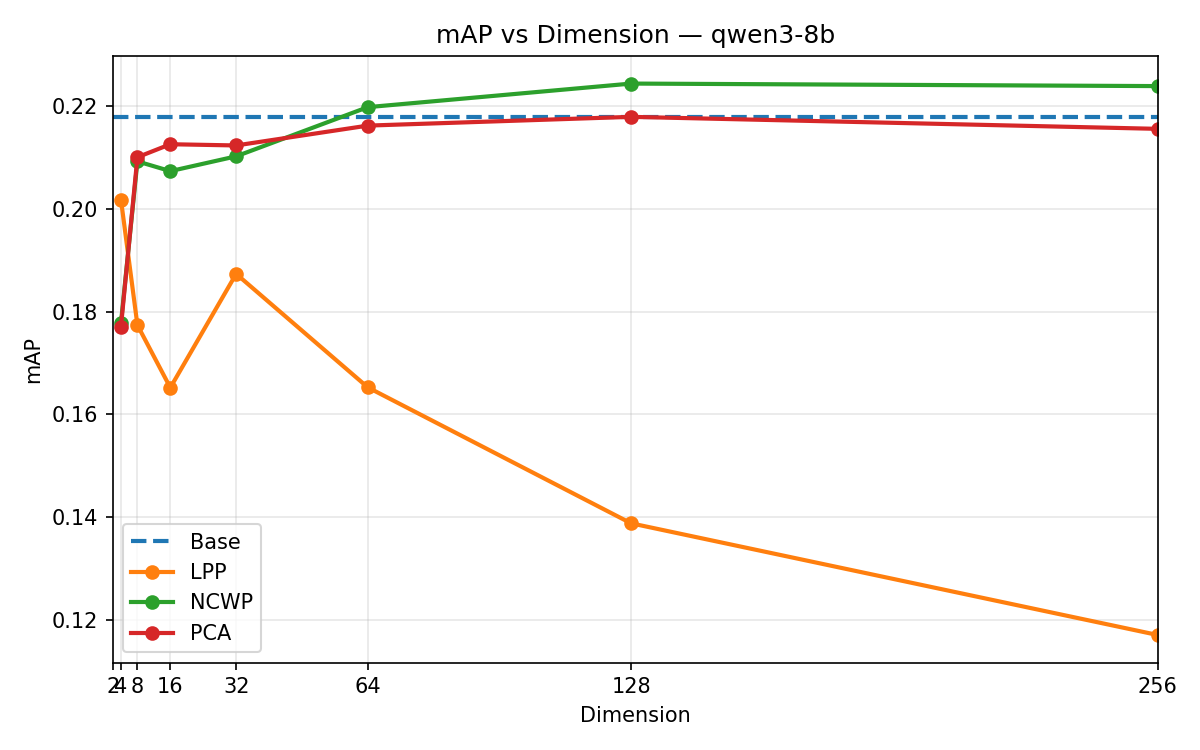

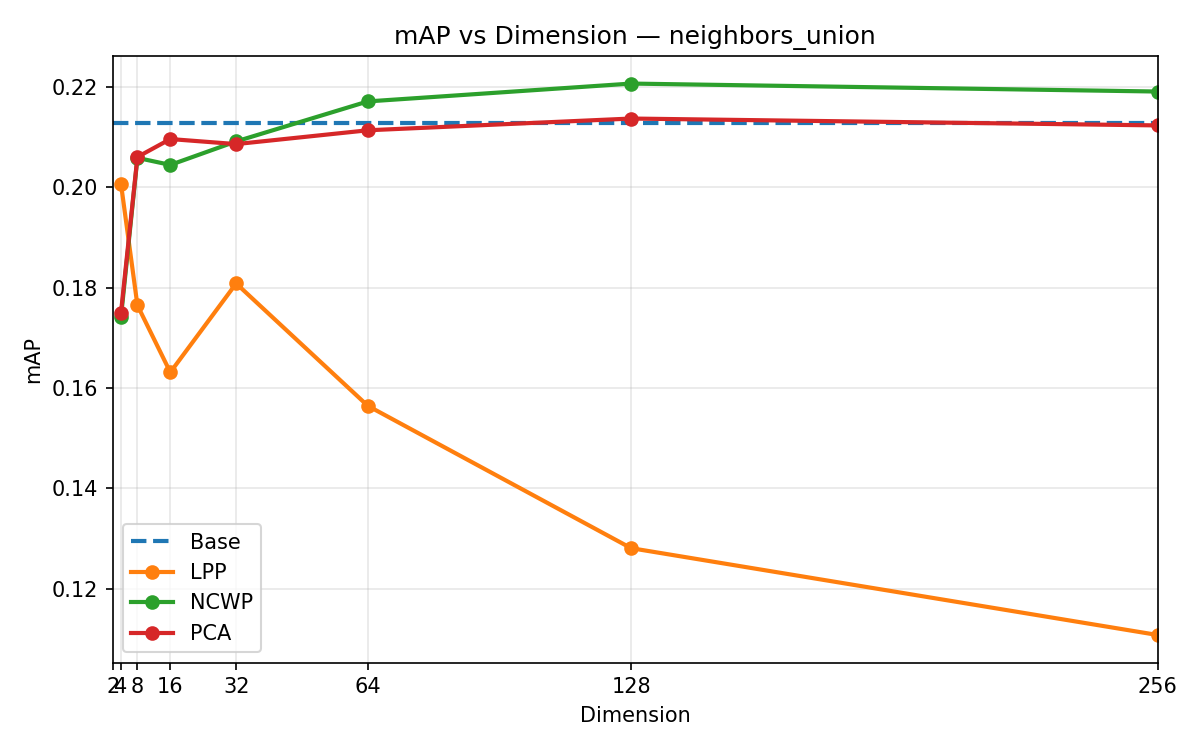

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/bpe/metrics_panels_nvidia_llama-embed-nemotron-8b.png


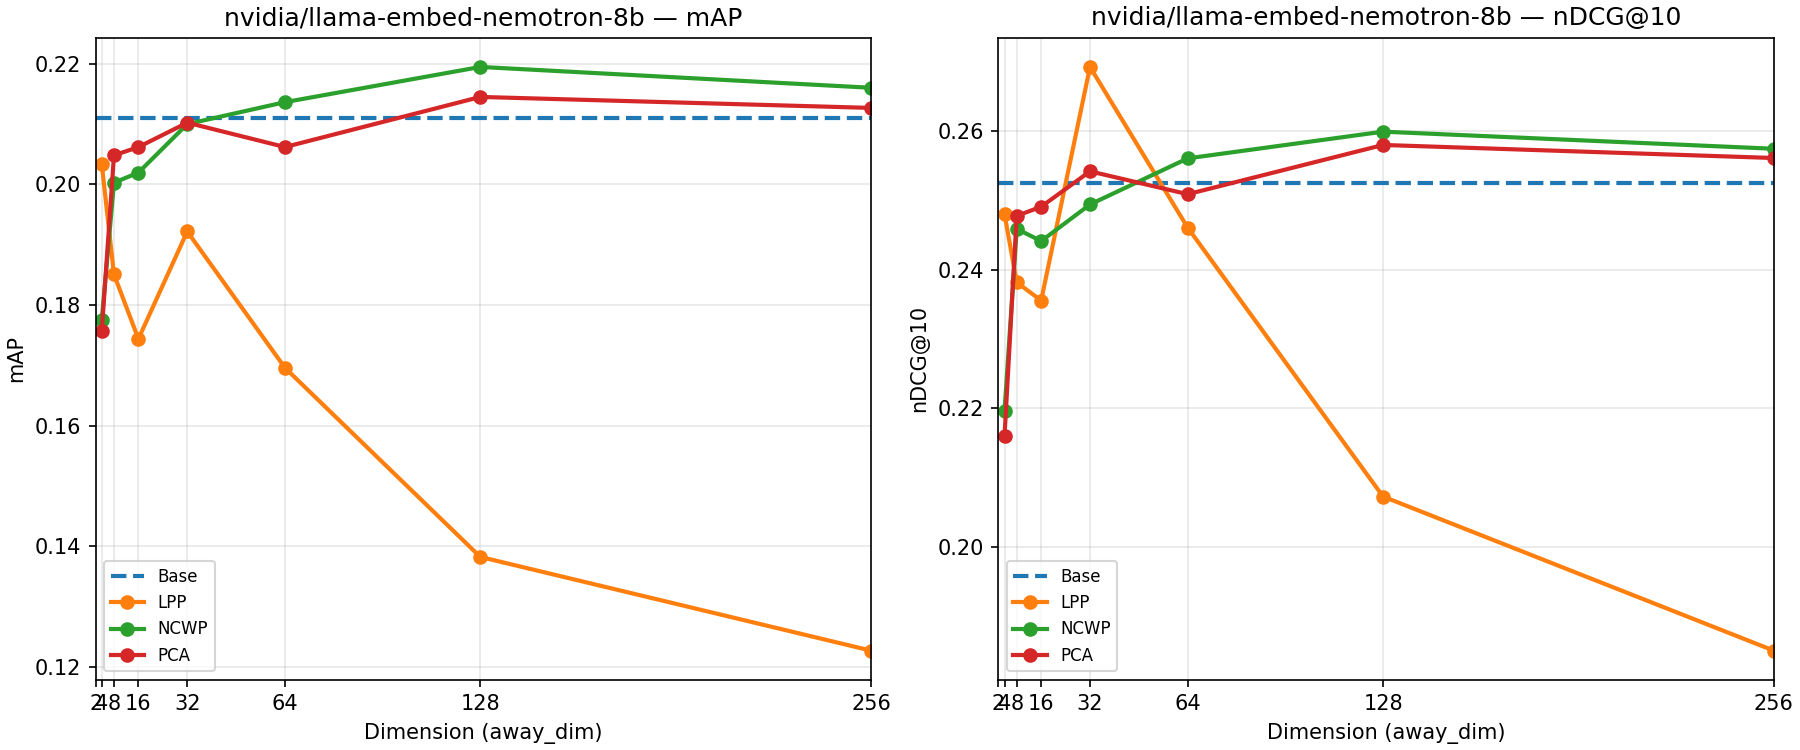

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/bpe/metrics_panels_qwen3-4b.png


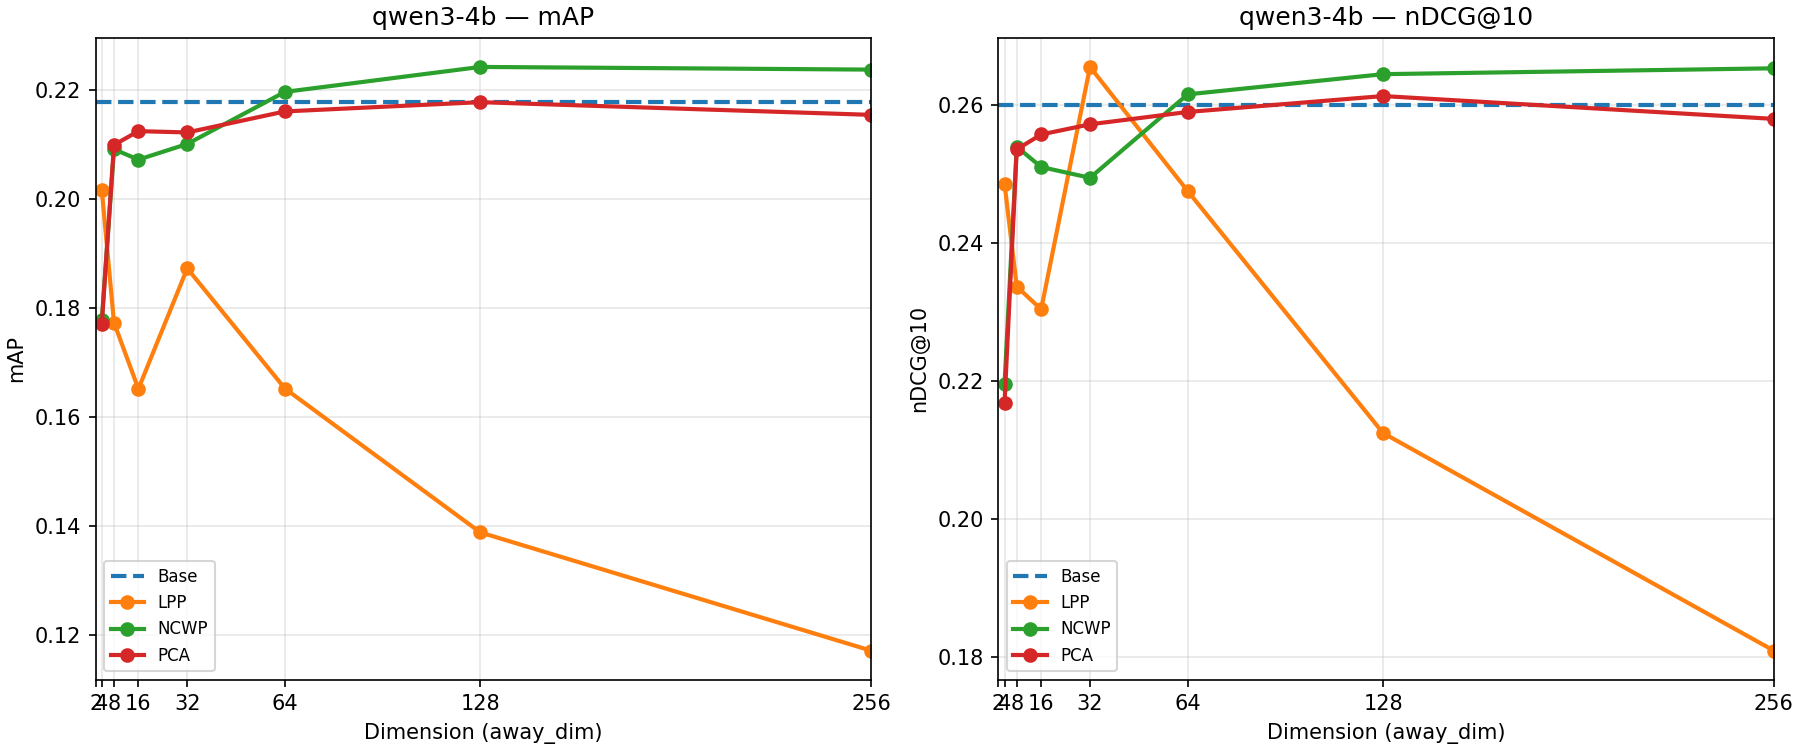

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/bpe/metrics_panels_qwen3-8b.png


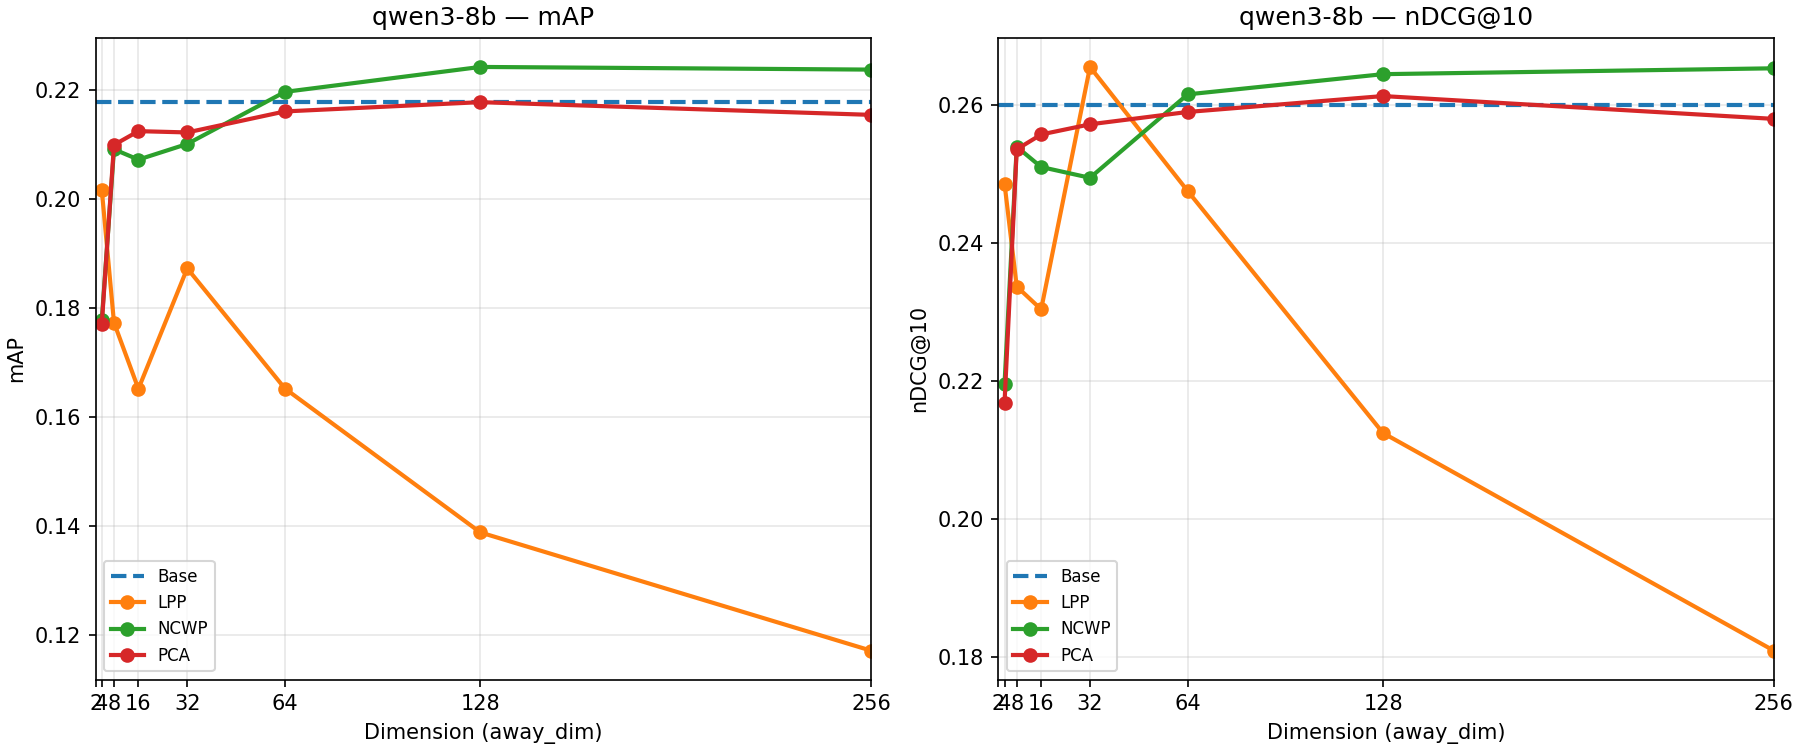

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/bpe/metrics_panels_neighbors_union.png


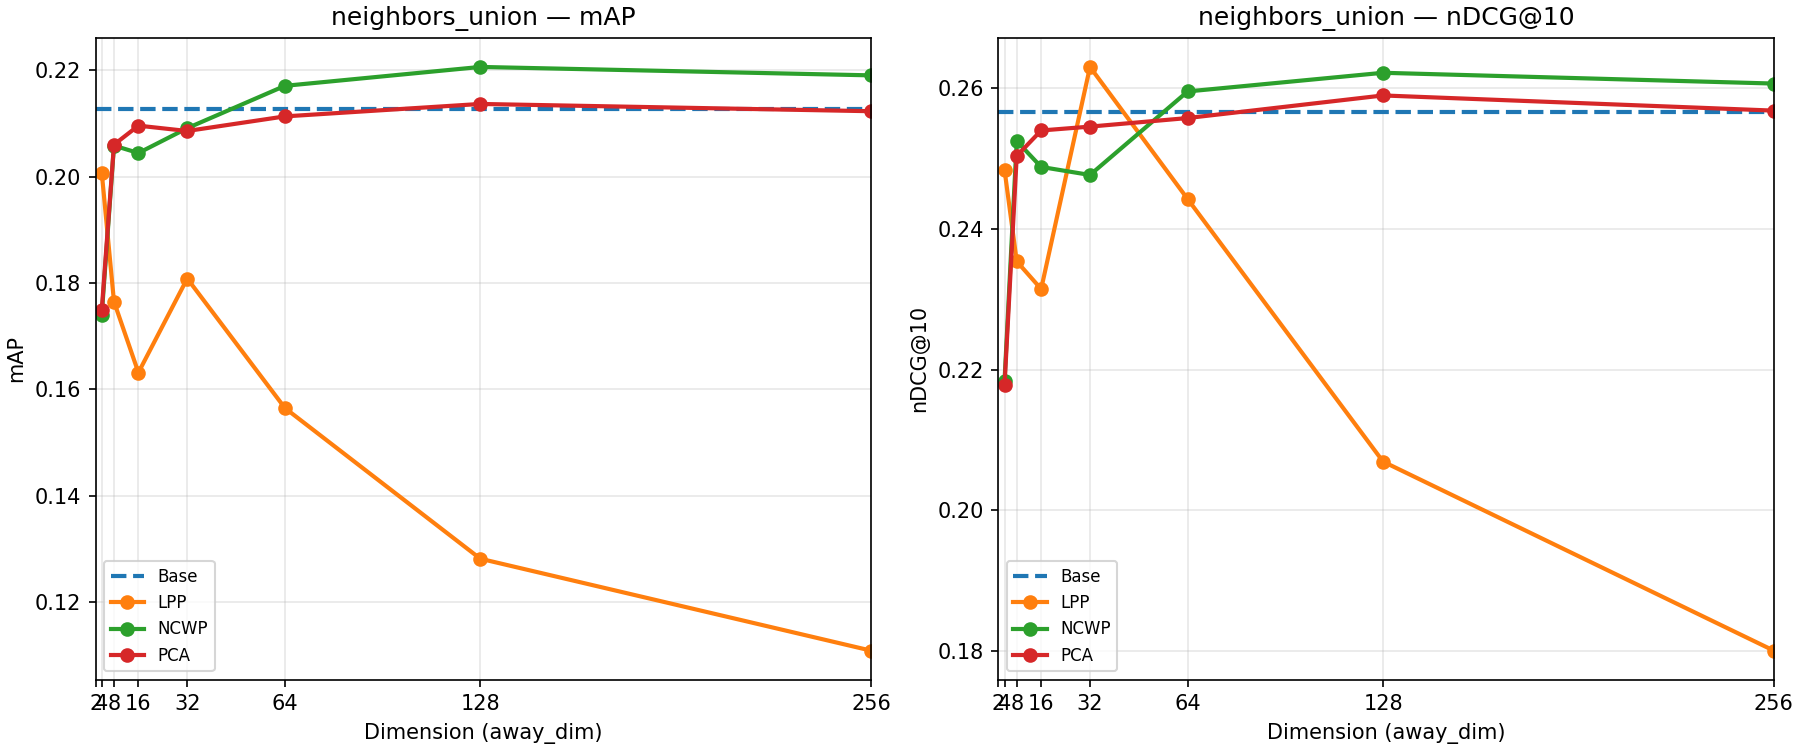

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/wordpiece/comparison.csv
Saved plot: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/wordpiece/map_vs_dim.png


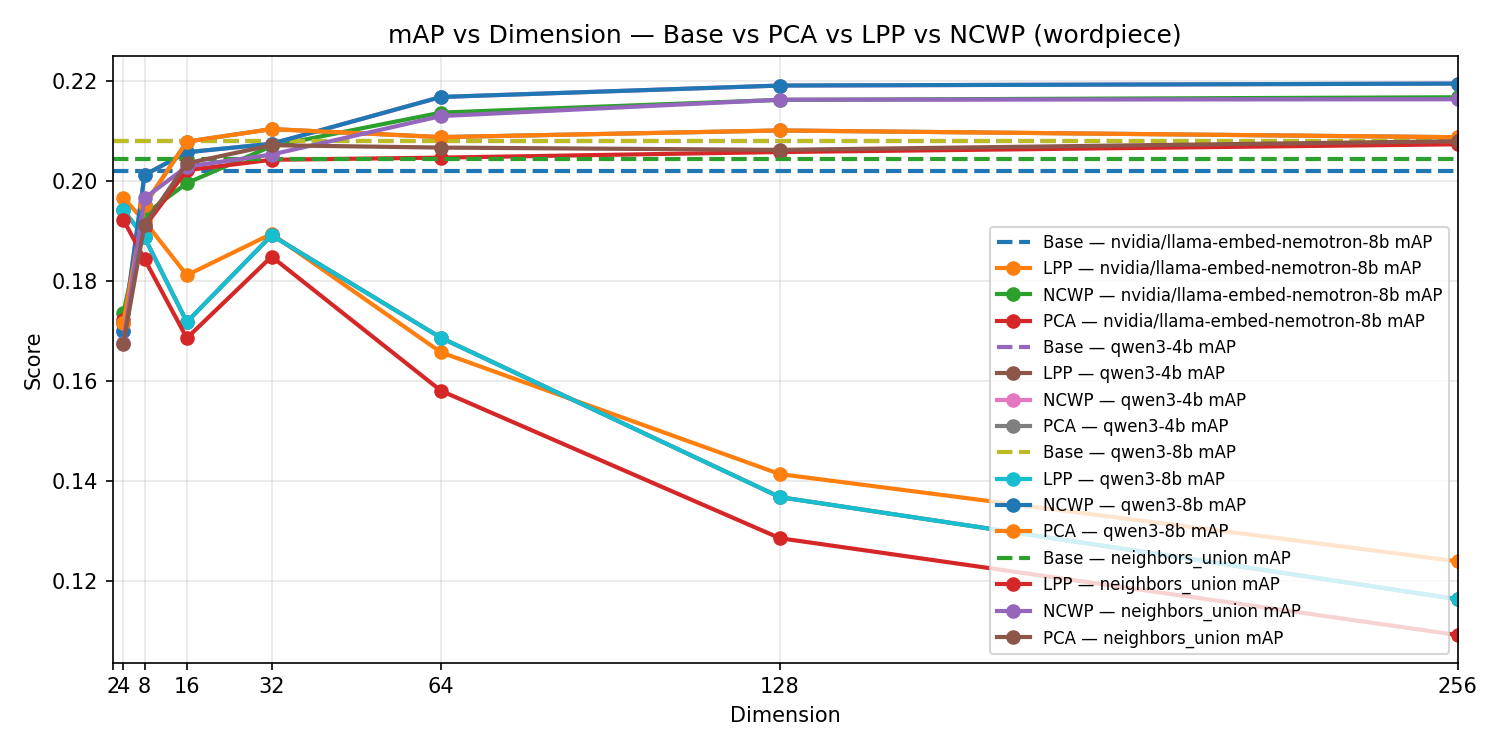

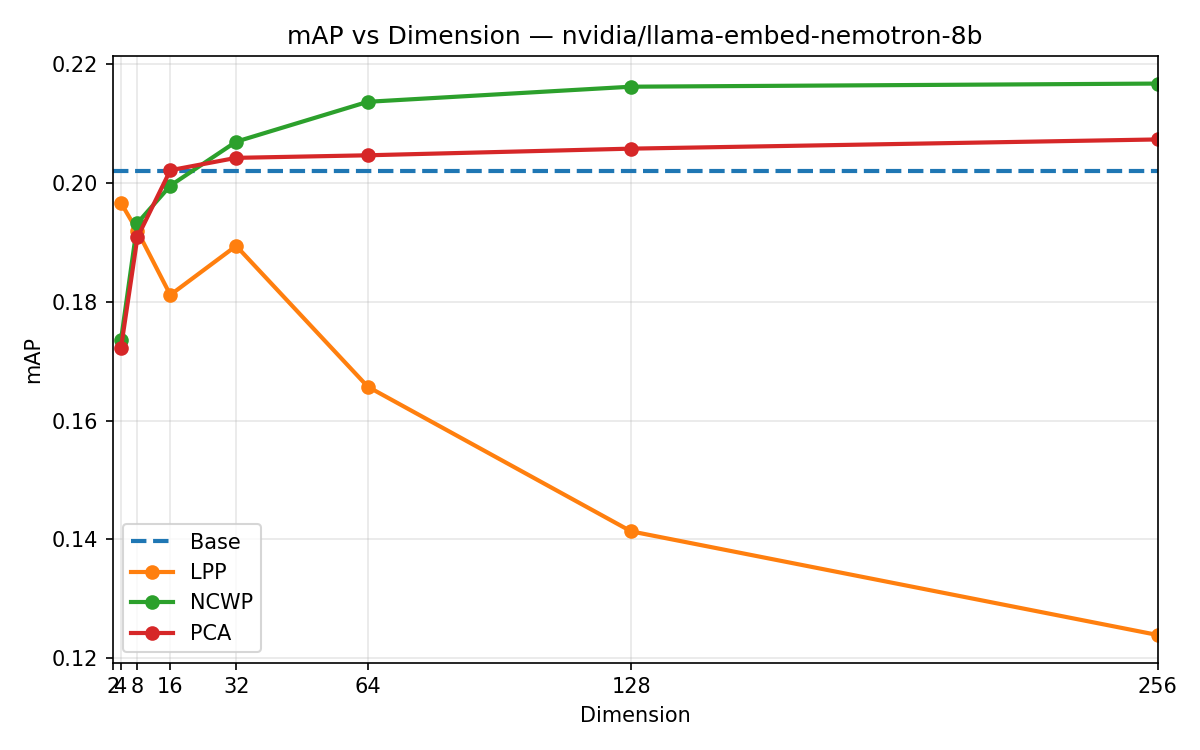

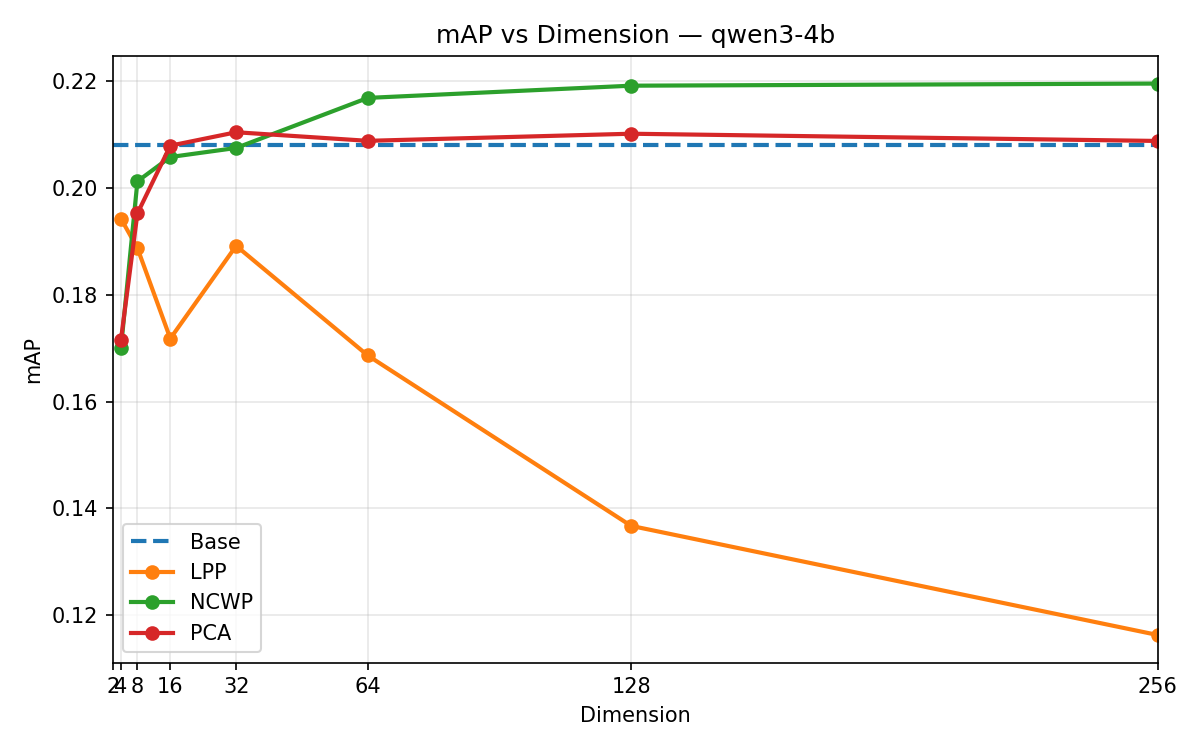

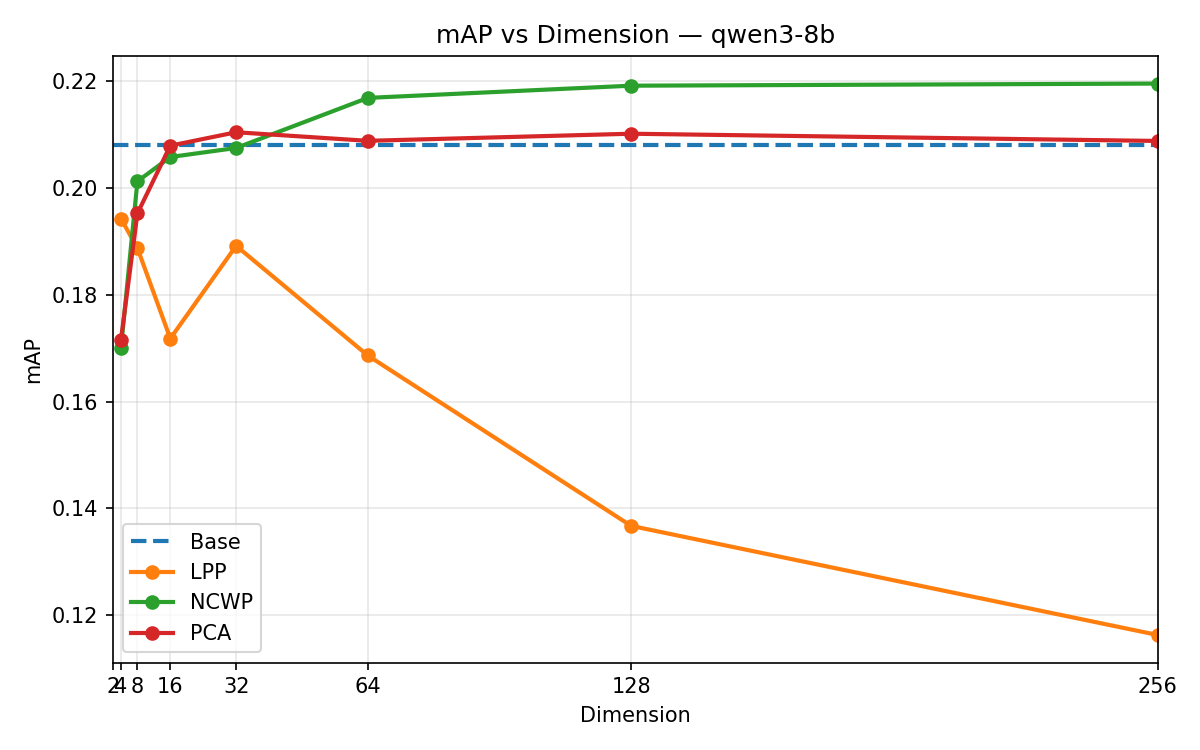

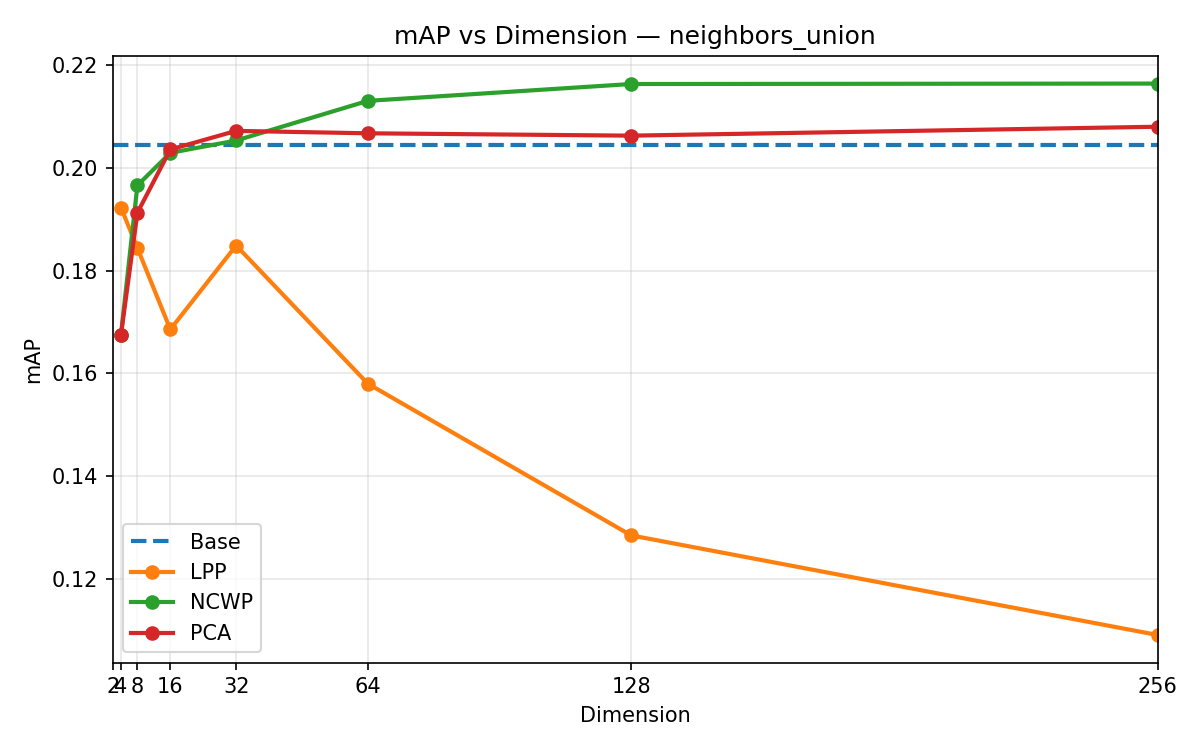

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/wordpiece/metrics_panels_nvidia_llama-embed-nemotron-8b.png


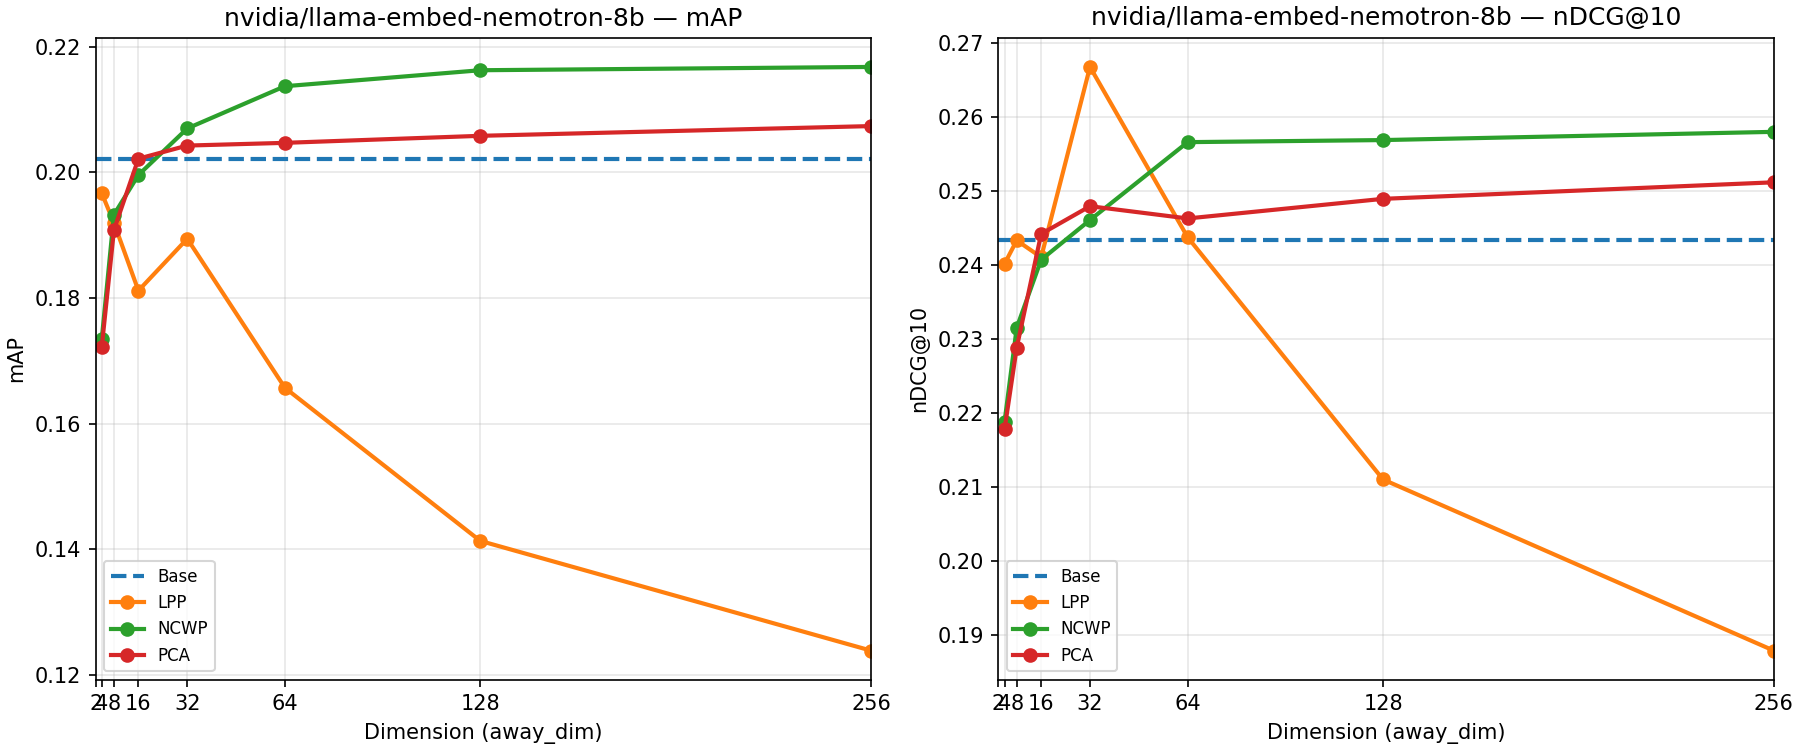

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/wordpiece/metrics_panels_qwen3-4b.png


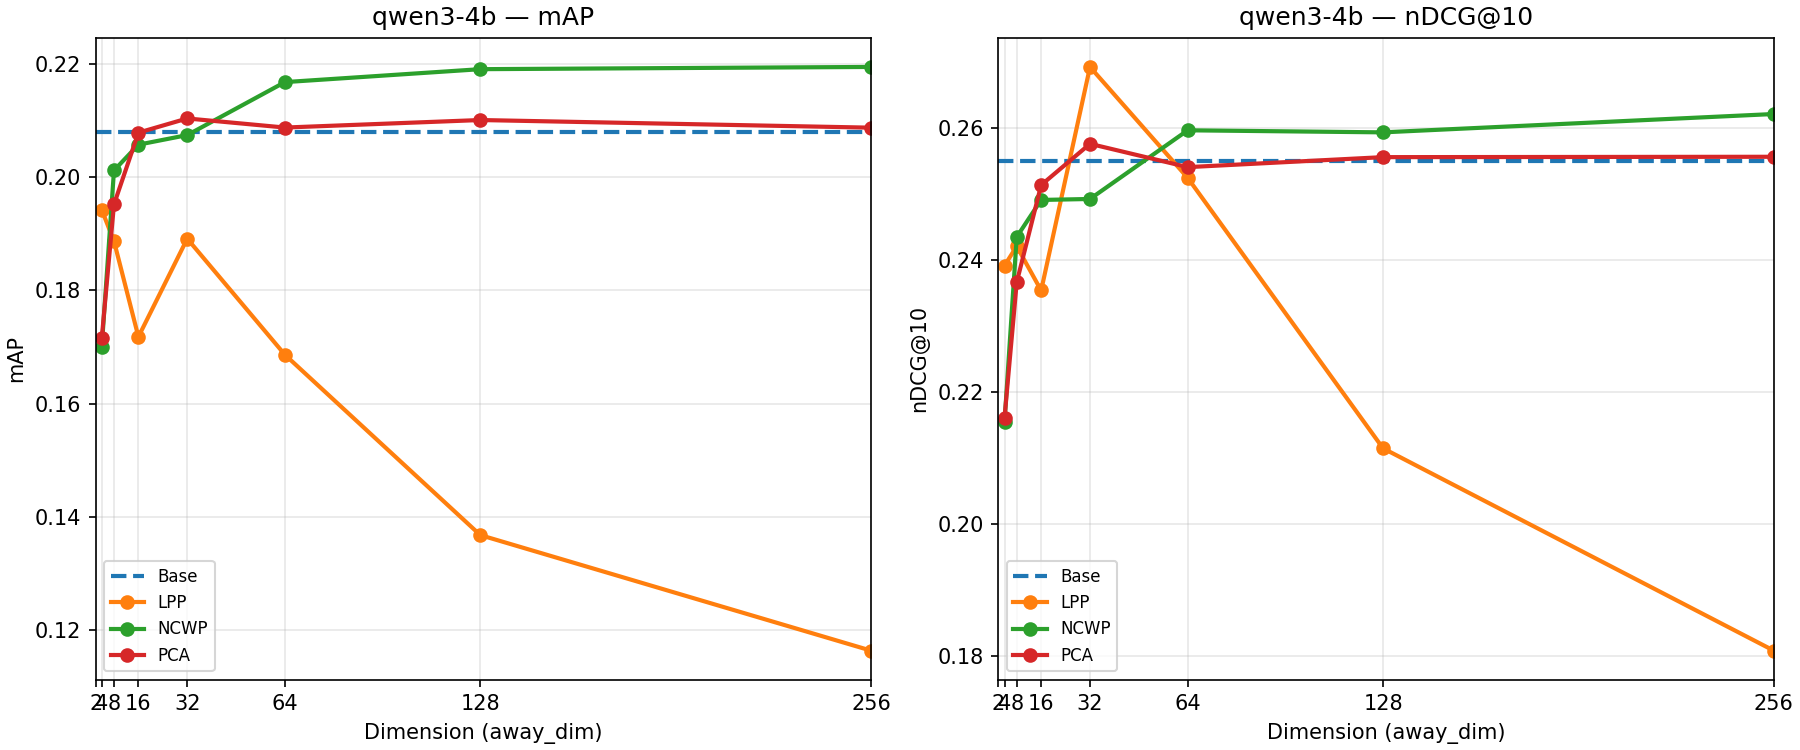

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/wordpiece/metrics_panels_qwen3-8b.png


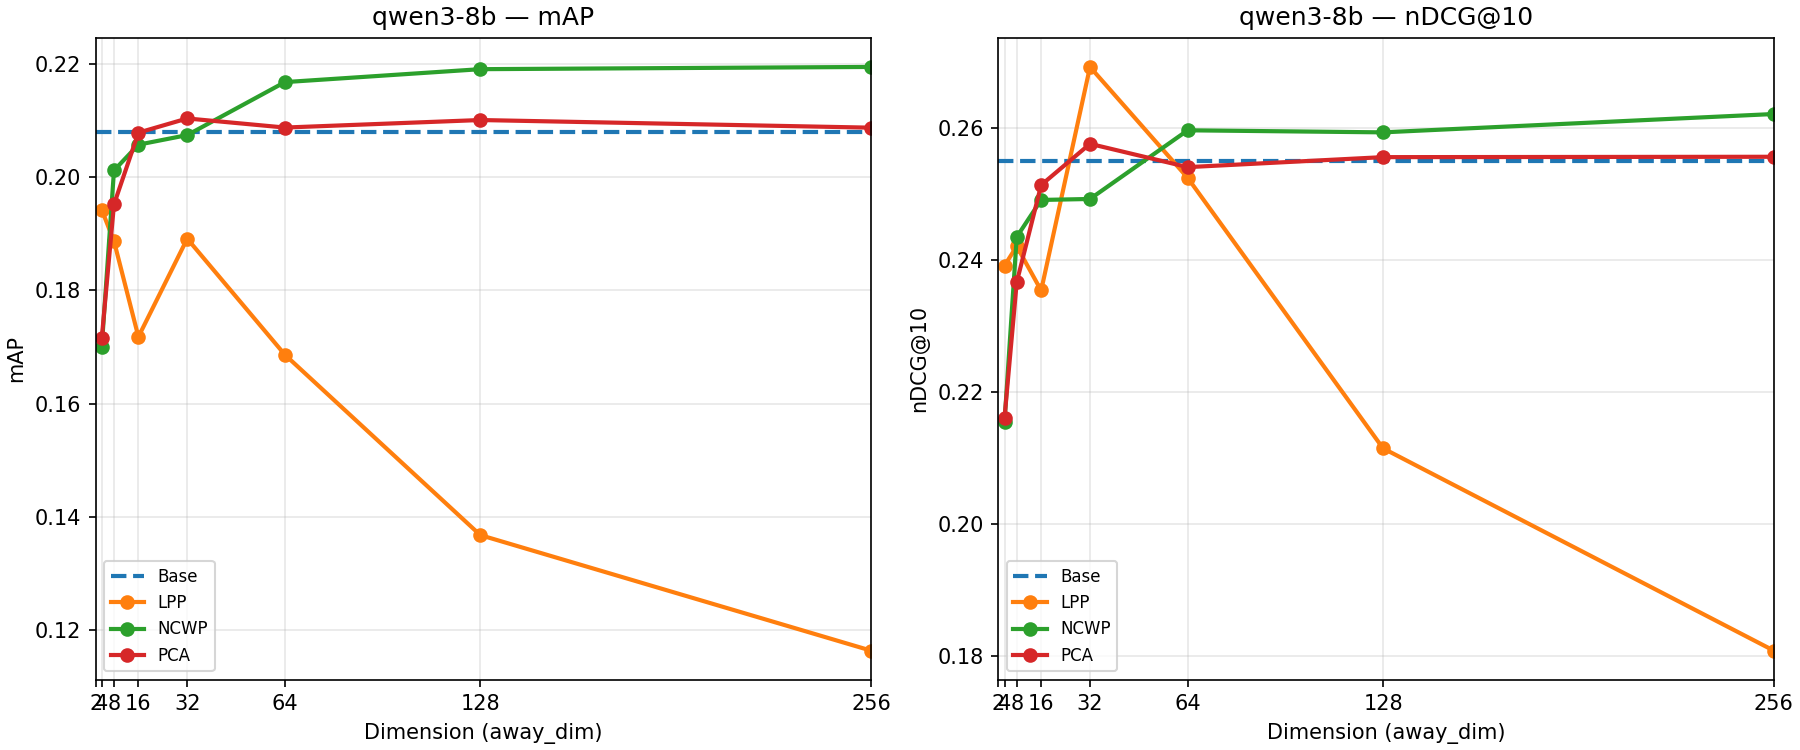

Saved: /home/workspace/Make_embedding/NCWP/ncwp_eval/results/wordpiece/metrics_panels_neighbors_union.png


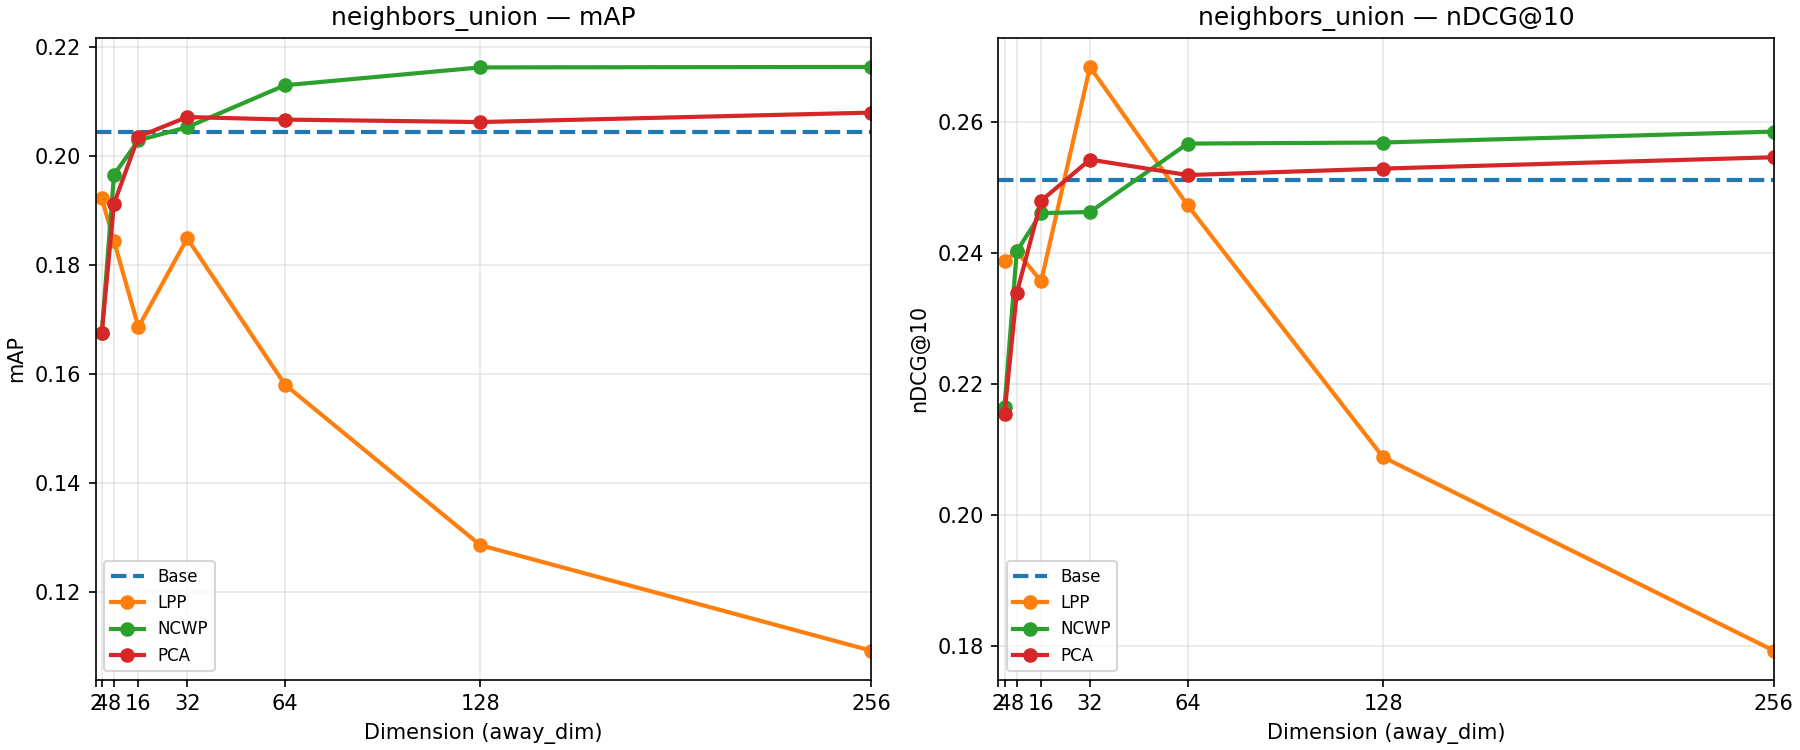

In [ ]:
# Save CSV and plots per tokenizer
from pathlib import Path

for tok, df in dfs.items():
    out_dir_tok = os.path.join(OUT_DIR, tok)
    Path(out_dir_tok).mkdir(parents=True, exist_ok=True)

    out_csv = os.path.join(out_dir_tok, "comparison.csv")
    df.to_csv(out_csv, index=False)
    print("Saved:", out_csv)

    # Prepare metrics for plotting (mAP only for overview)
    metrics = []
    for col in ["nvidia/llama-embed-nemotron-8b", "qwen3-4b", "qwen3-8b", "neighbors_union"]:
        key = f"{col}_mAP"
        if key in df.columns:
            metrics.append((key, f"{col} mAP"))

    plot_path = os.path.join(out_dir_tok, "map_vs_dim.png")
    if metrics:
        # Overview with all labels together
        plot_metrics_vs_dim(df, metrics, f"mAP vs Dimension — Base vs PCA vs LPP vs NCWP ({tok})", plot_path)
        print("Saved plot:", plot_path)

        # 라벨별 mAP 그래프 (각 라벨 1장씩)
        labels = [m[0].replace("_mAP", "") for m in metrics]
        plot_per_label_maps(df, labels, out_dir_tok, prefix="map_vs_dim")

        # 라벨별 2‑패널 그래프 (mAP / nDCG@maxK)
        for lab in labels:
            panel_path = os.path.join(out_dir_tok, f"metrics_panels_{lab.replace('/', '_')}.png")
            plot_per_label_panels(df, lab, panel_path)
            print("Saved:", panel_path)
    else:
        print(f"No GT columns found for plotting for tok={tok}.")


[Display] tok=bpe


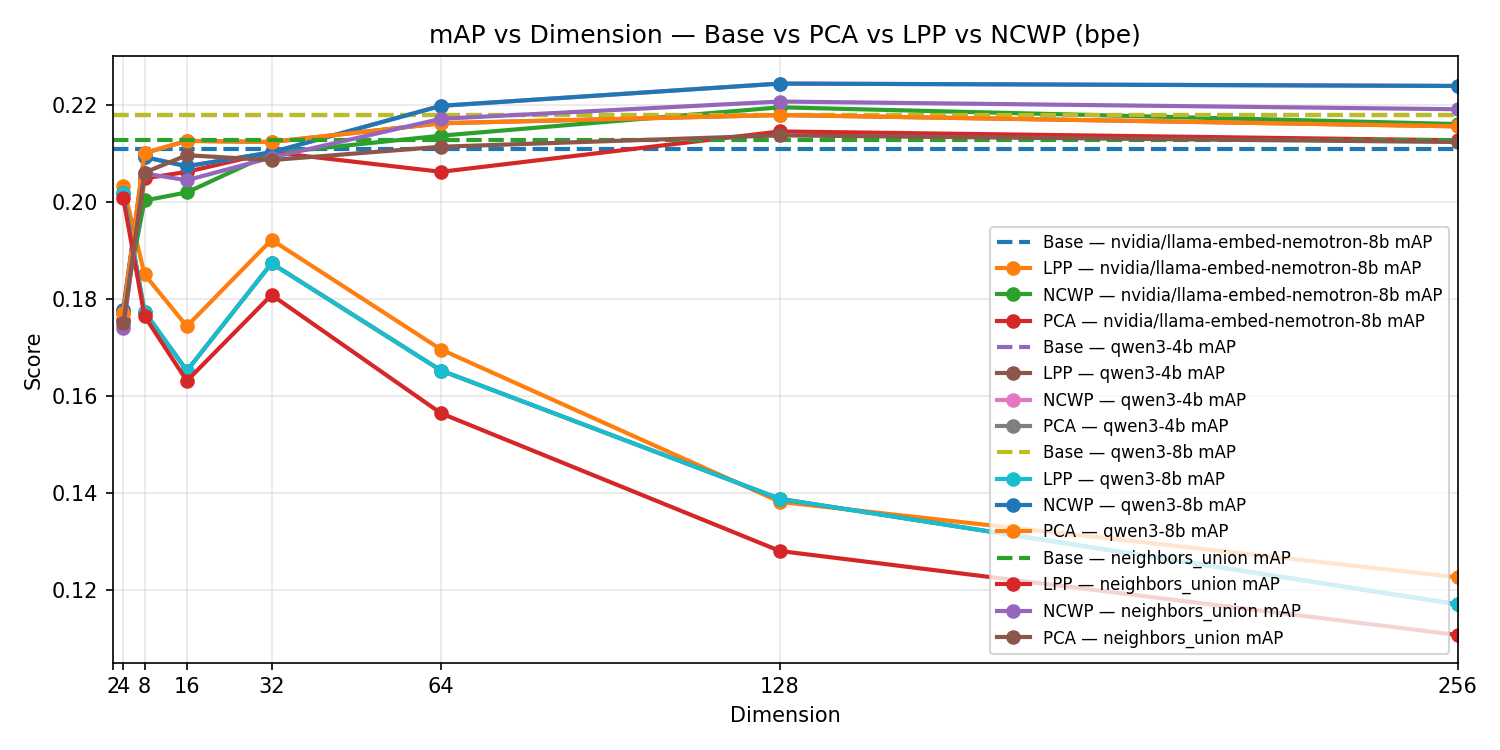

Labels: ['nvidia/llama-embed-nemotron-8b', 'qwen3-4b', 'qwen3-8b', 'neighbors_union']


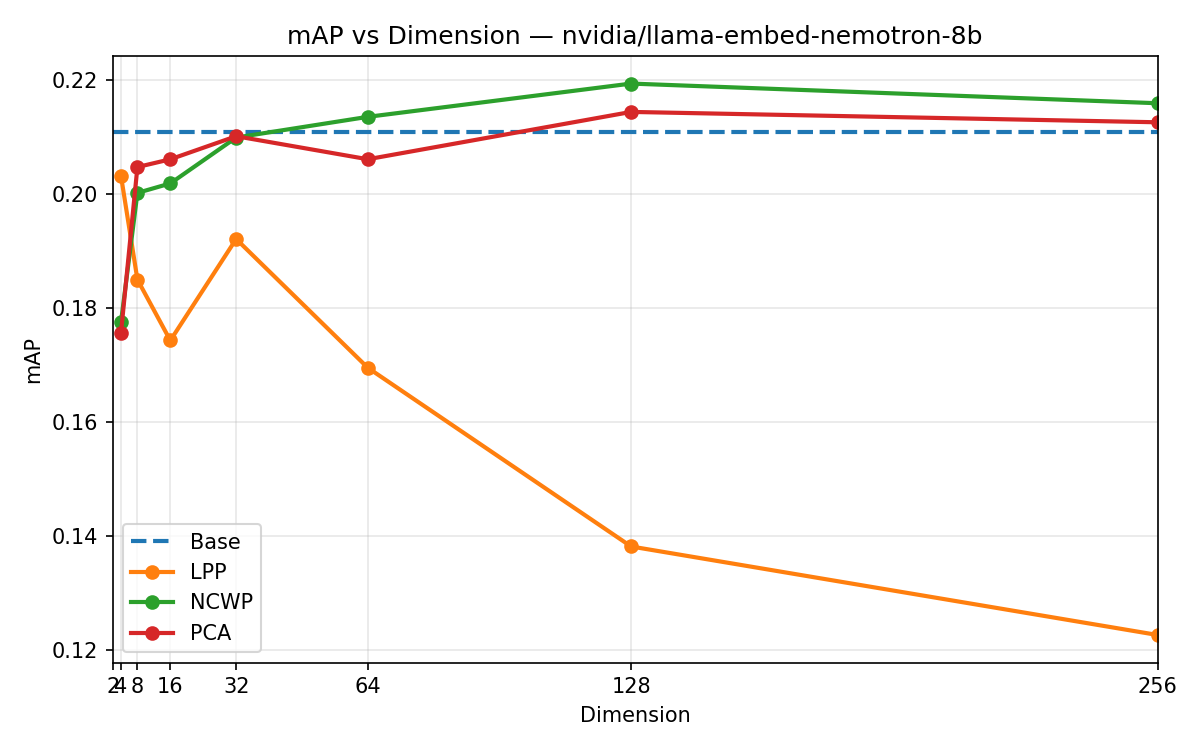

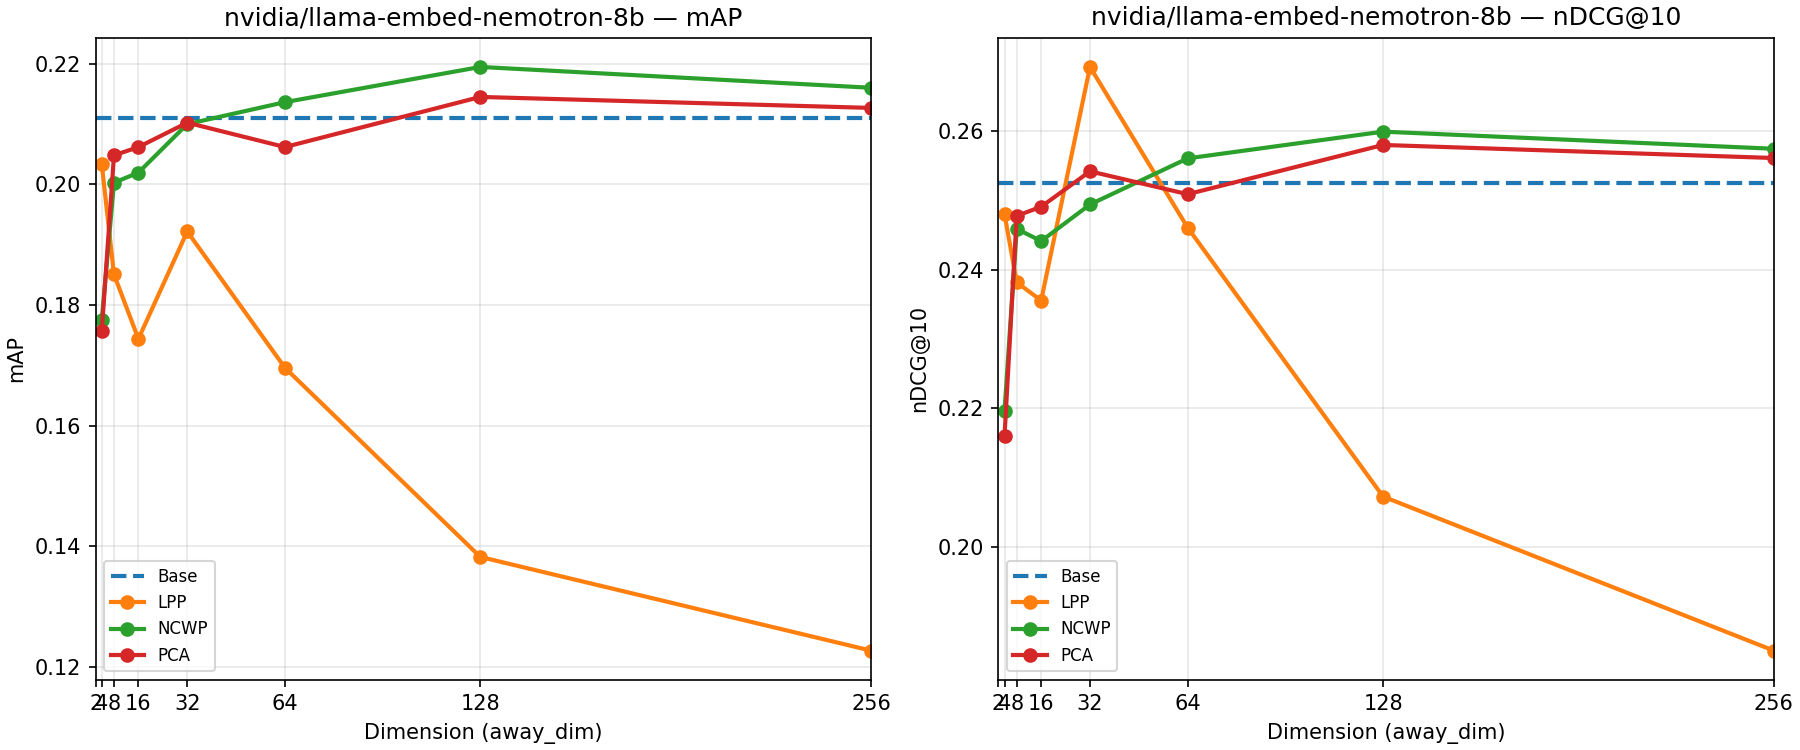

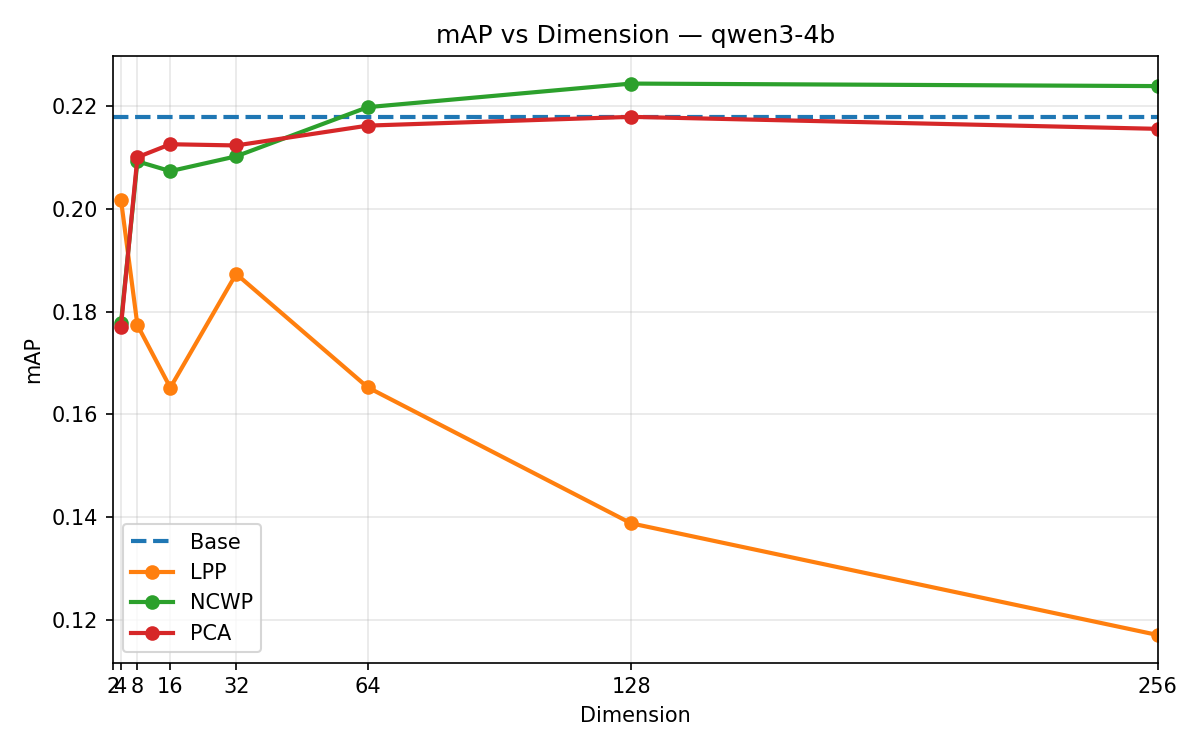

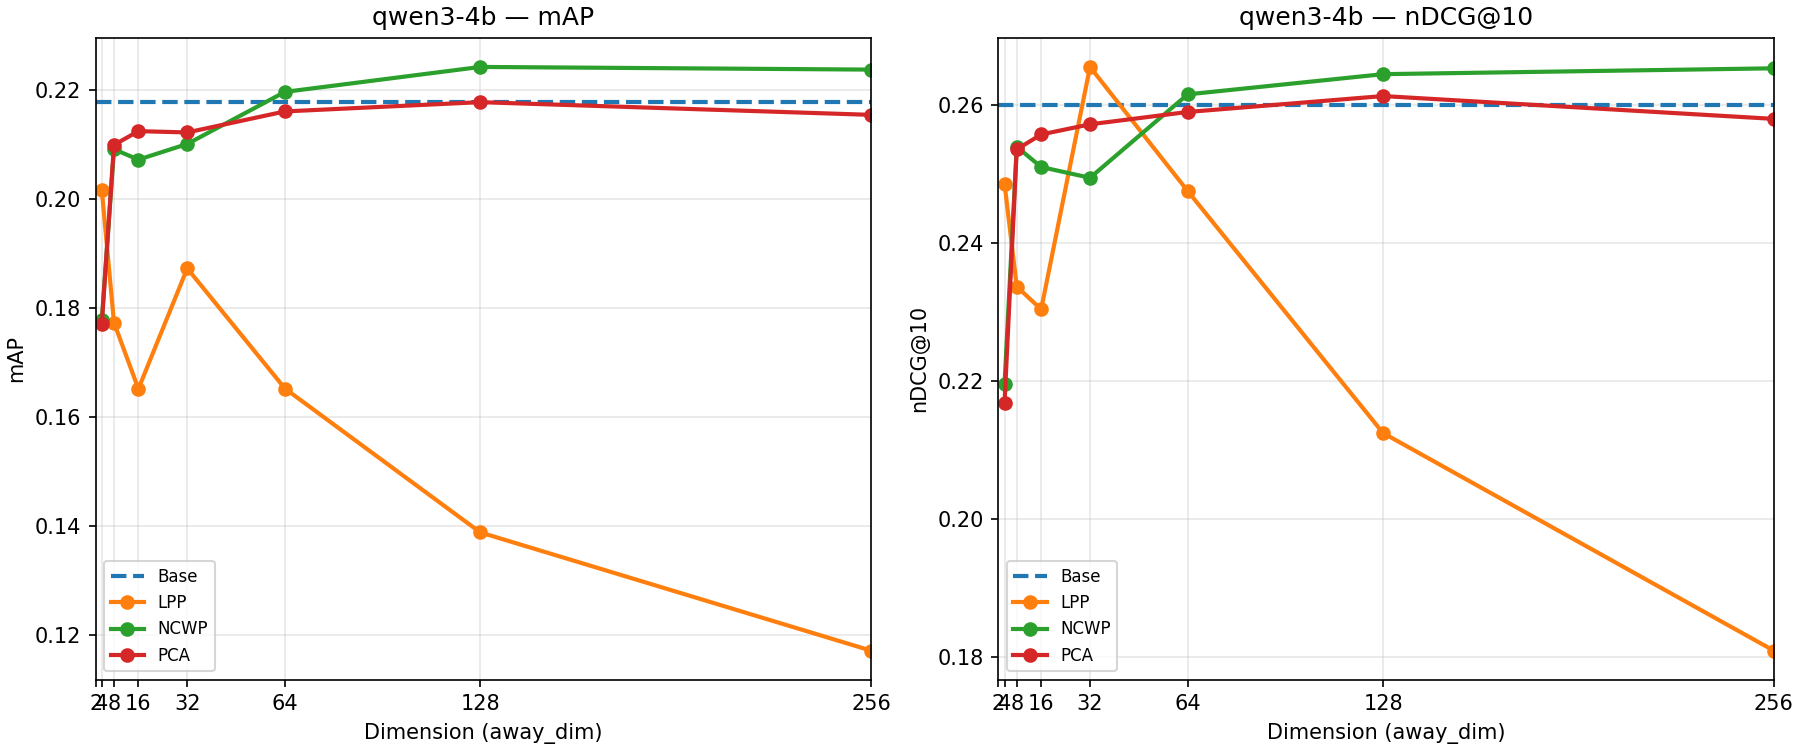

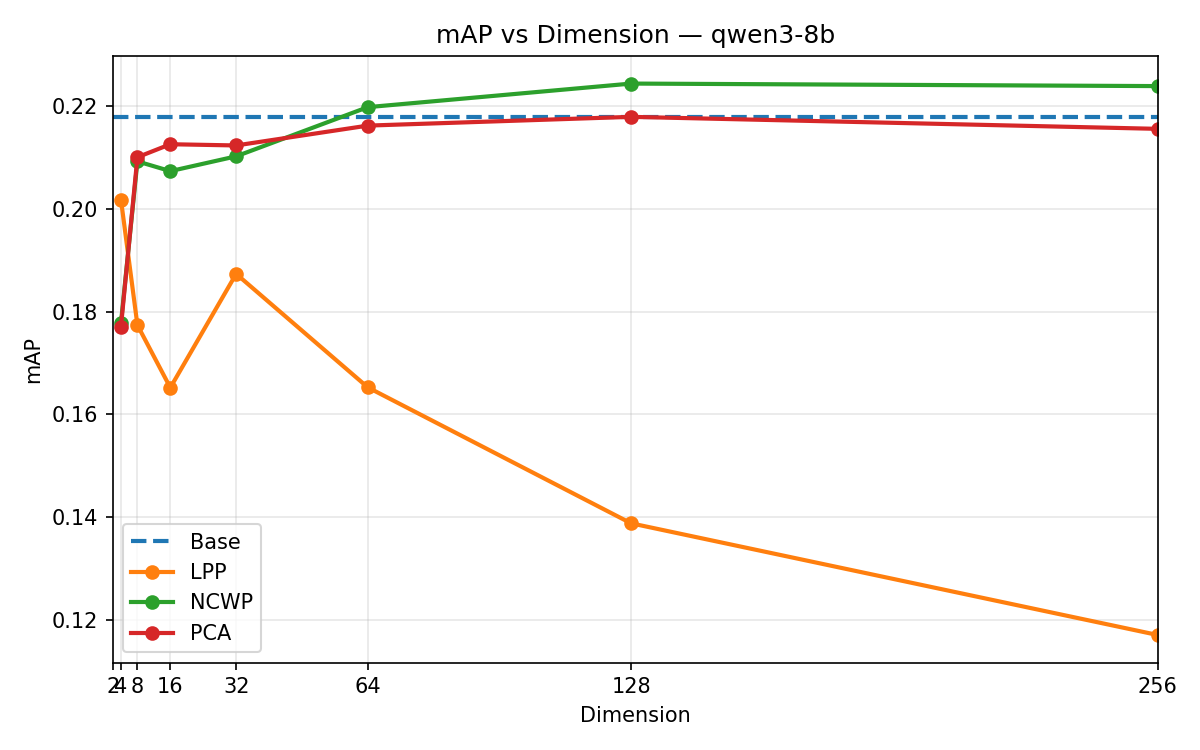

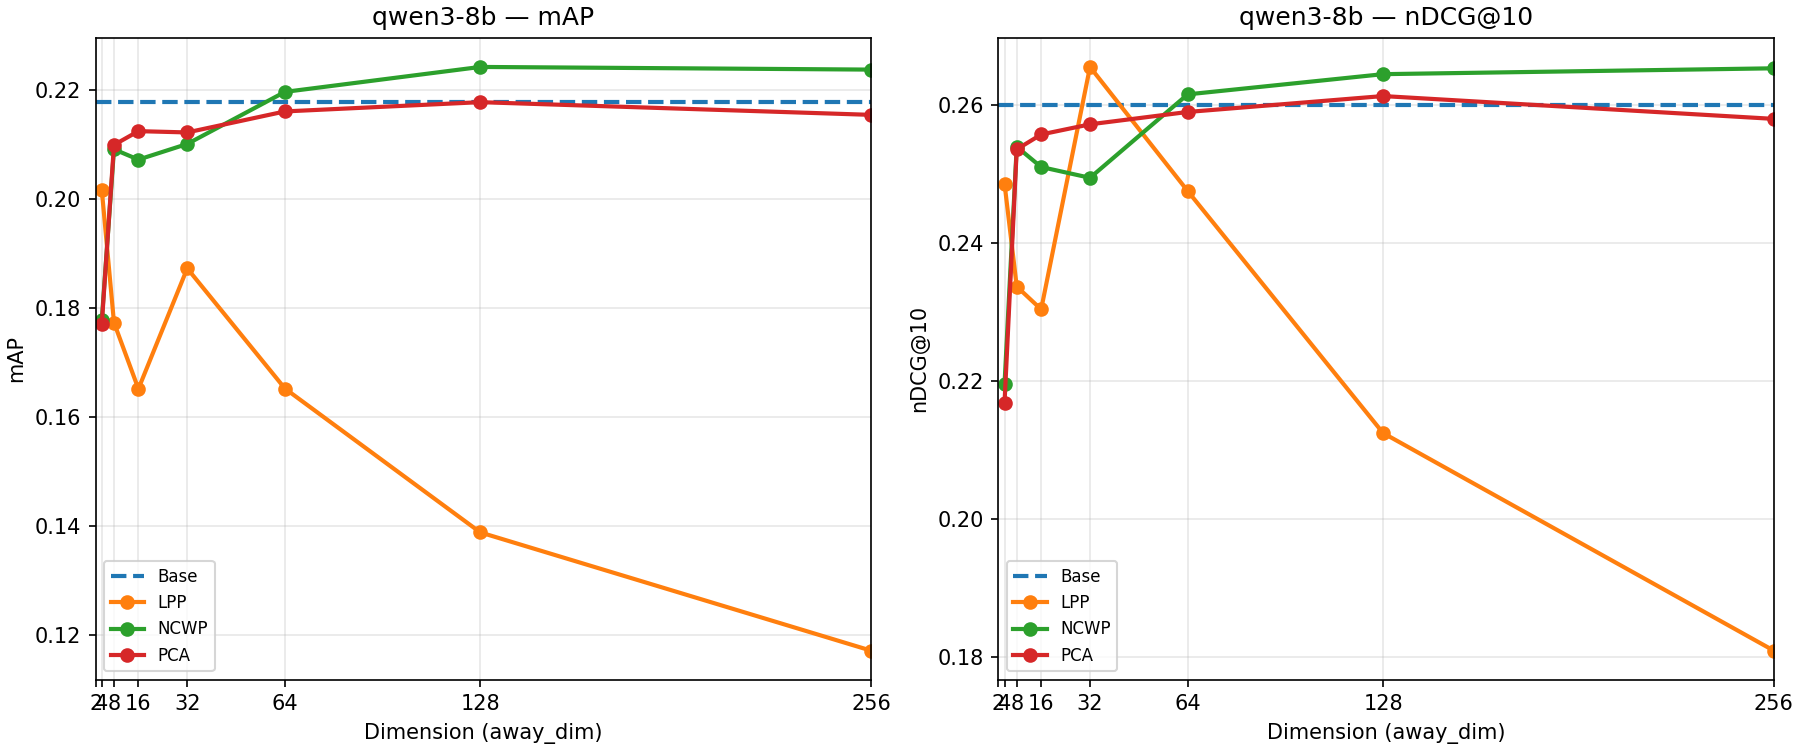

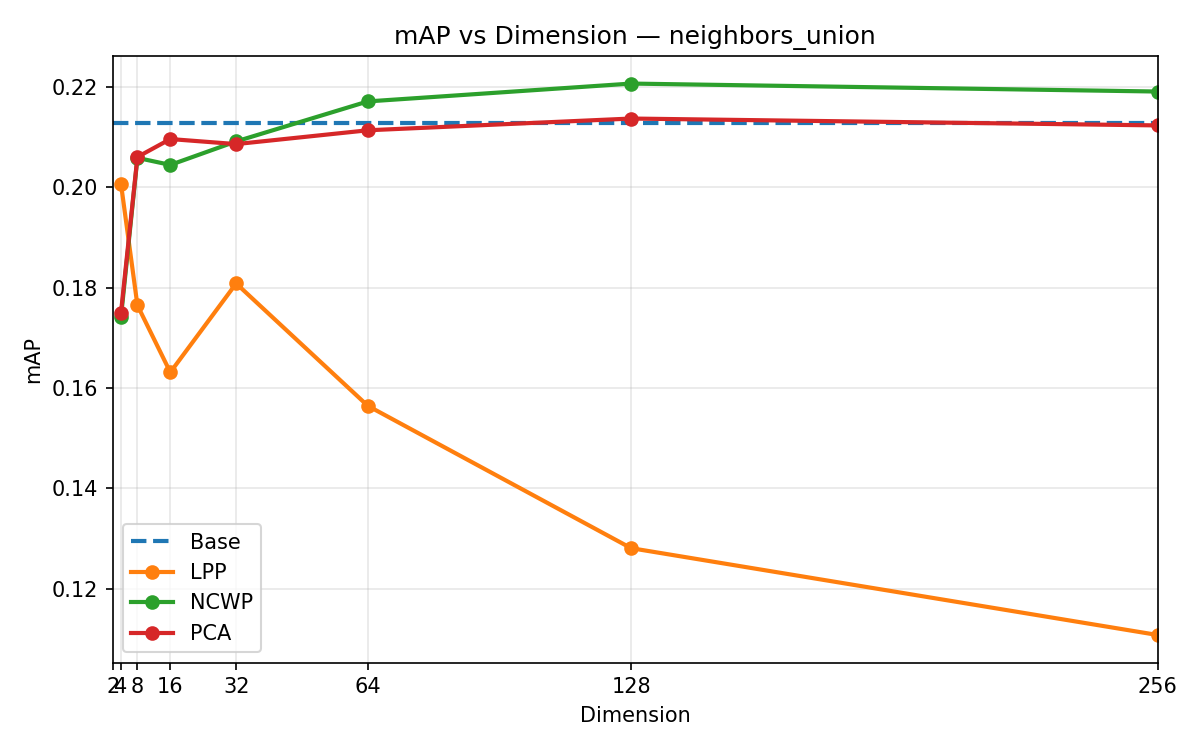

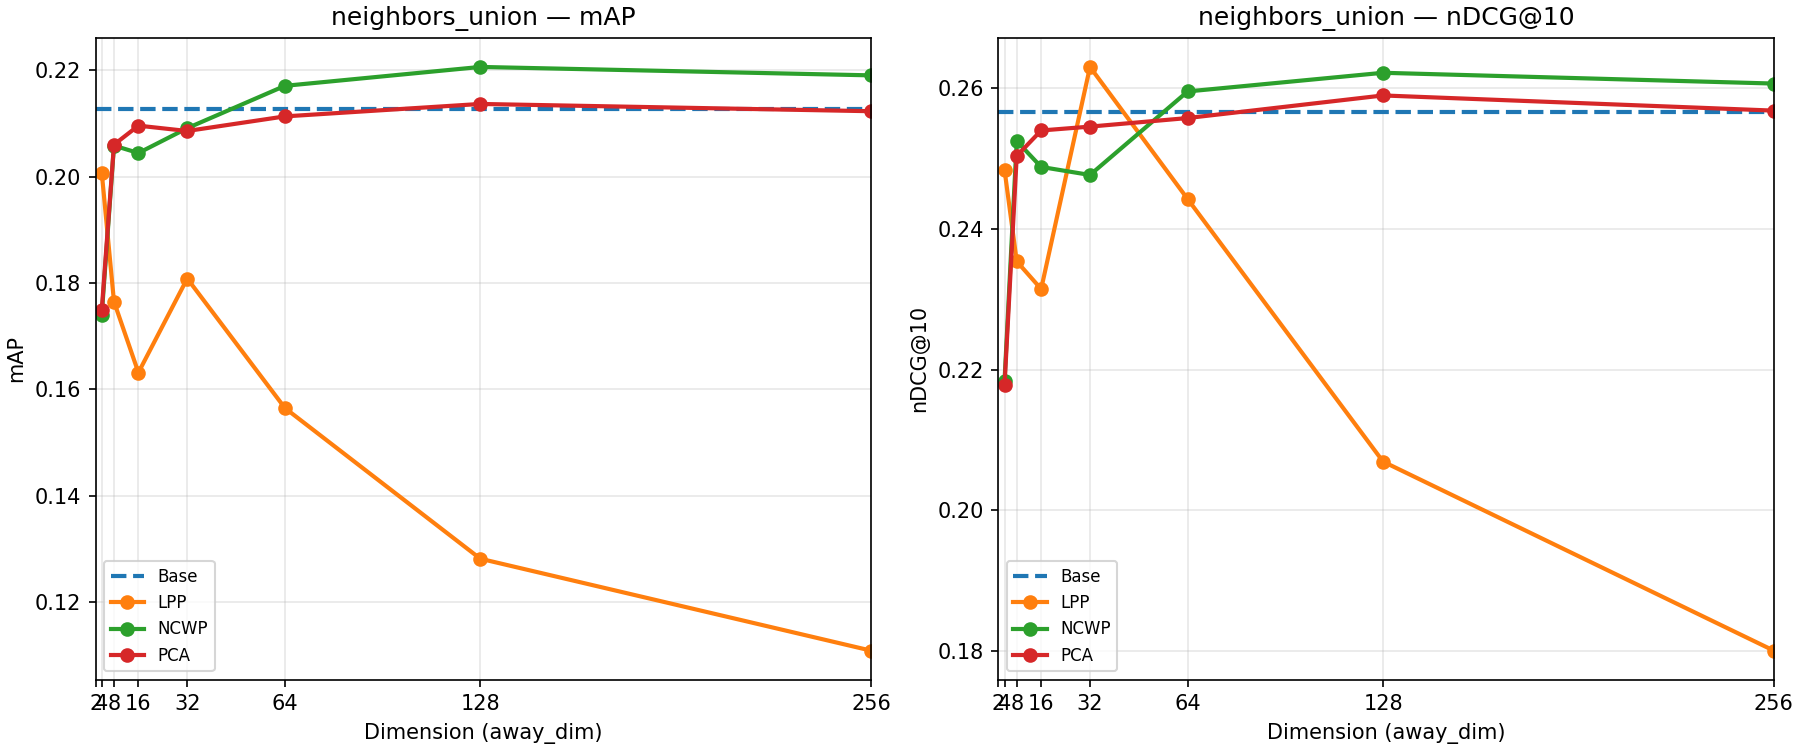

[Display] tok=wordpiece


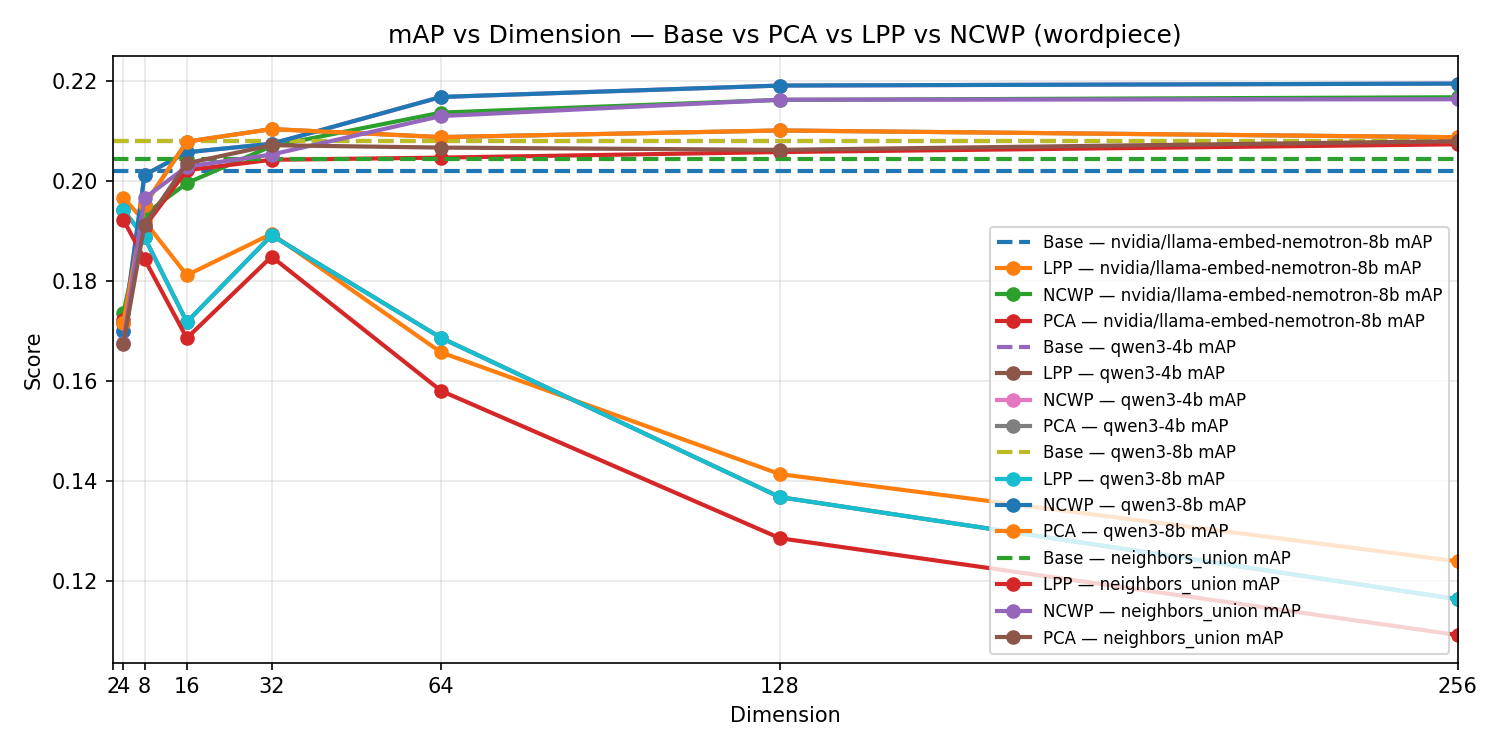

Labels: ['nvidia/llama-embed-nemotron-8b', 'qwen3-4b', 'qwen3-8b', 'neighbors_union']


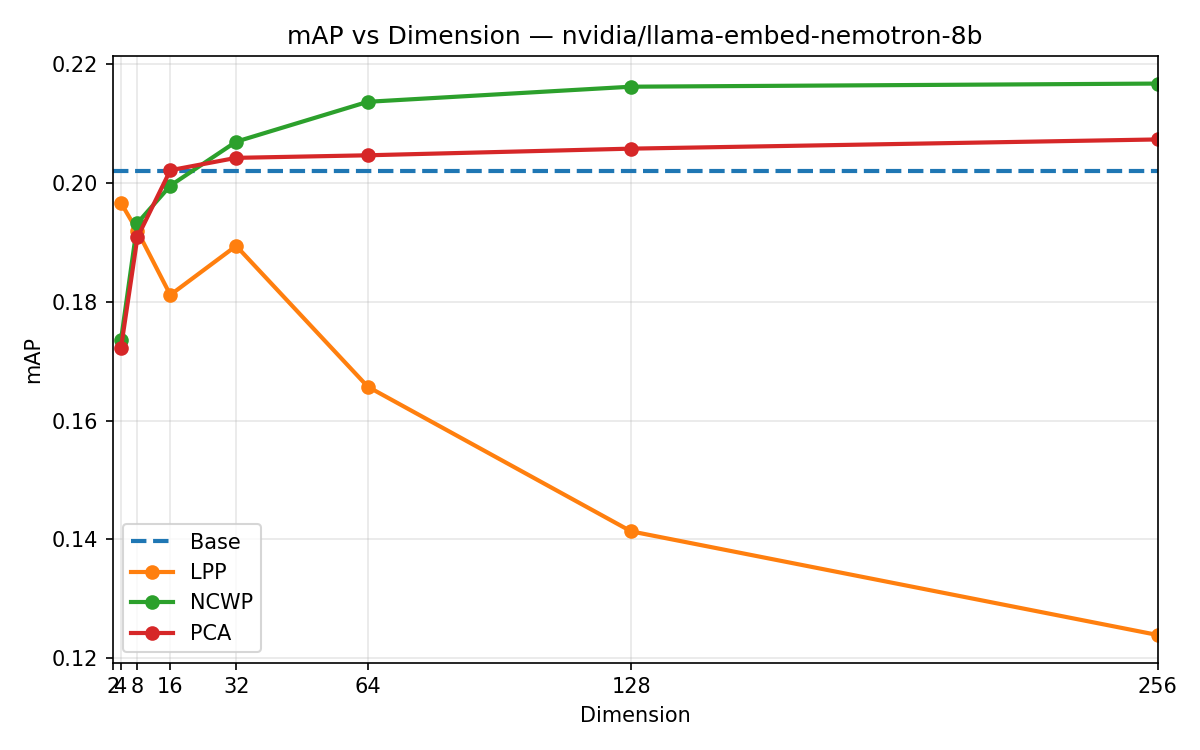

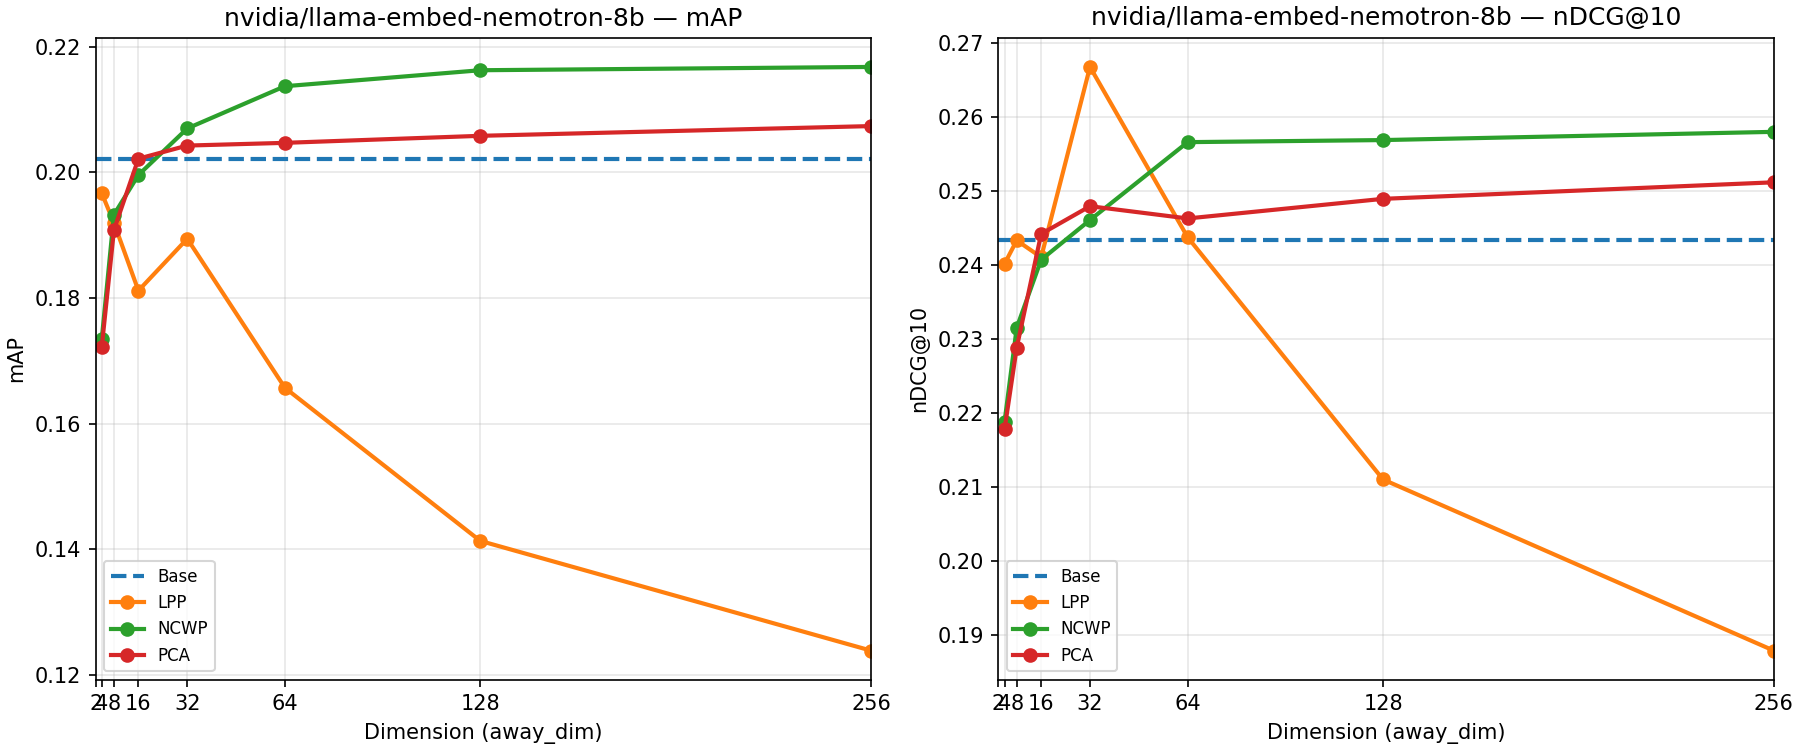

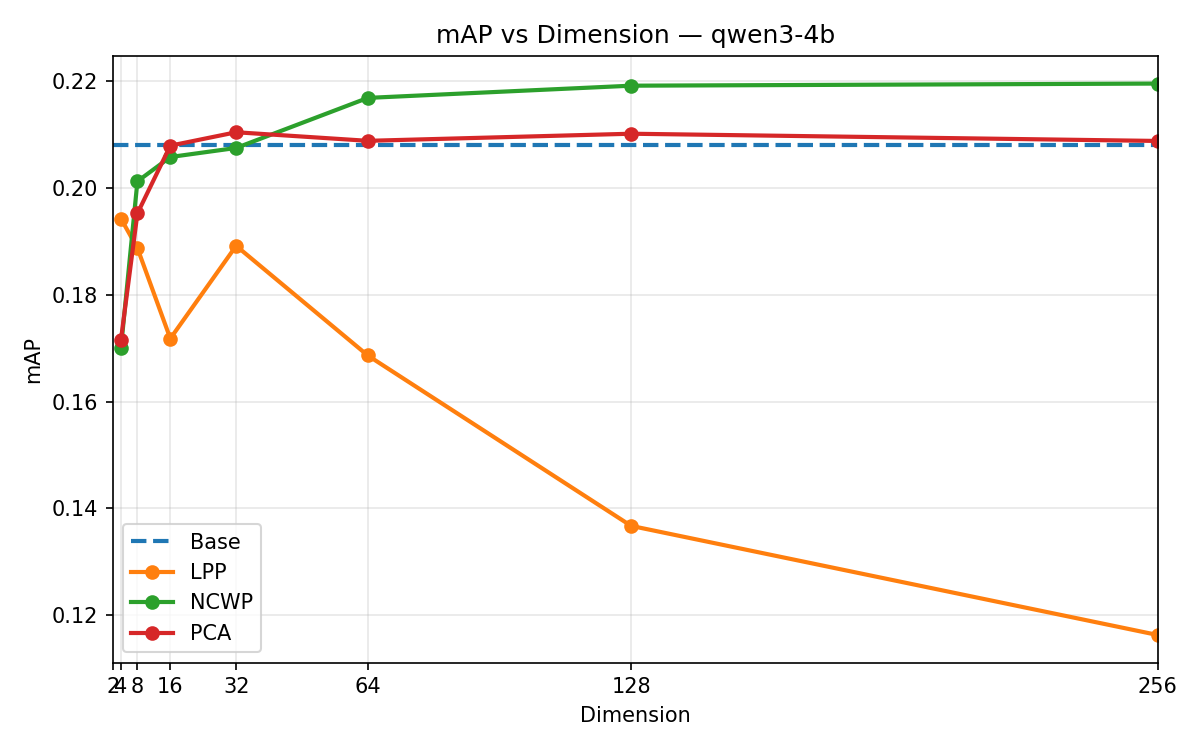

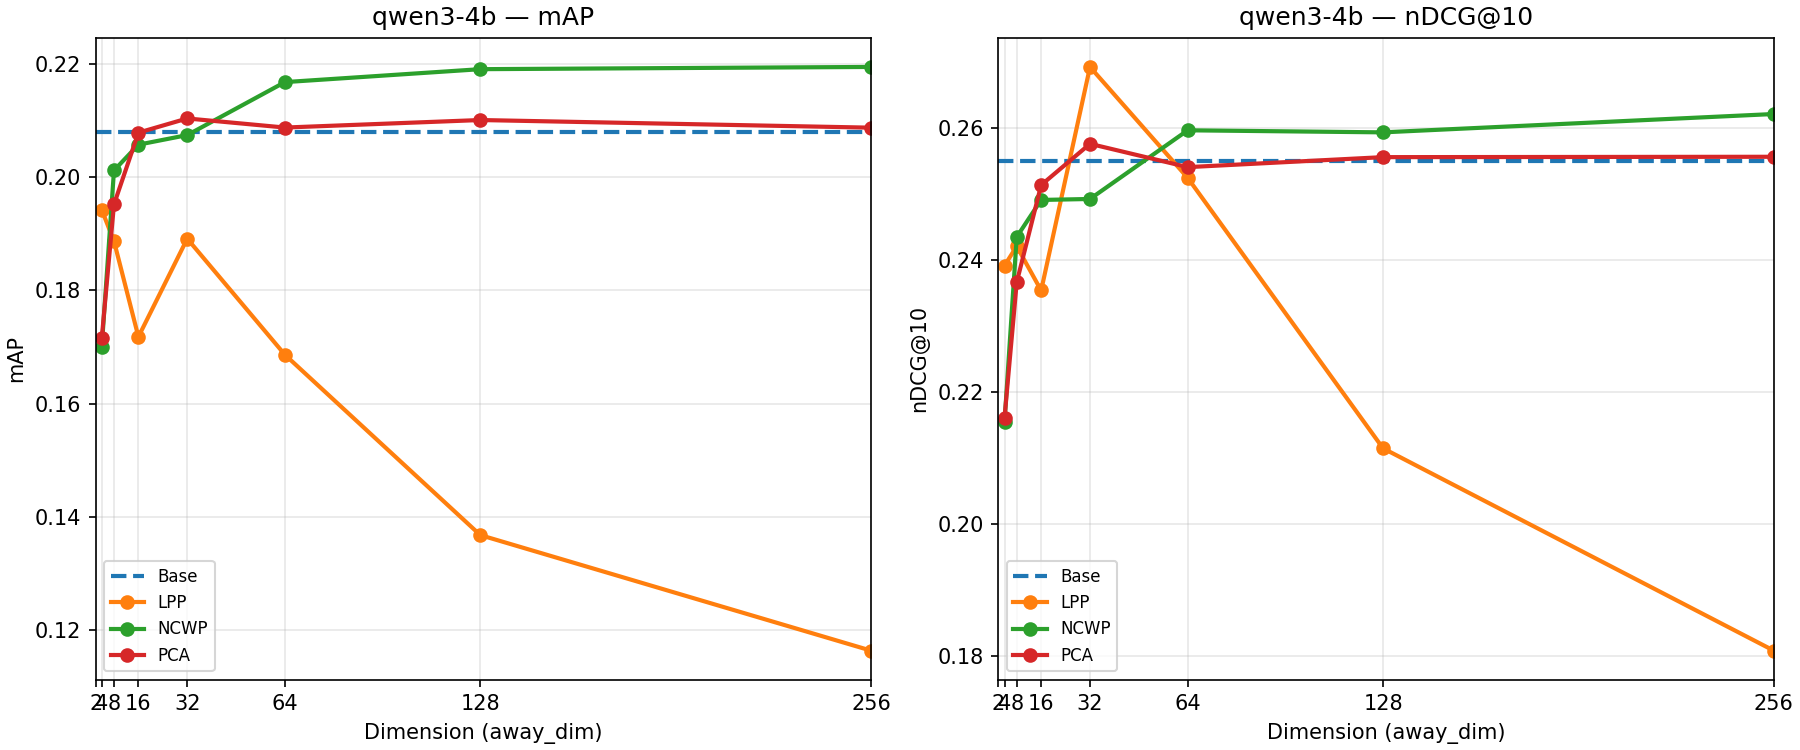

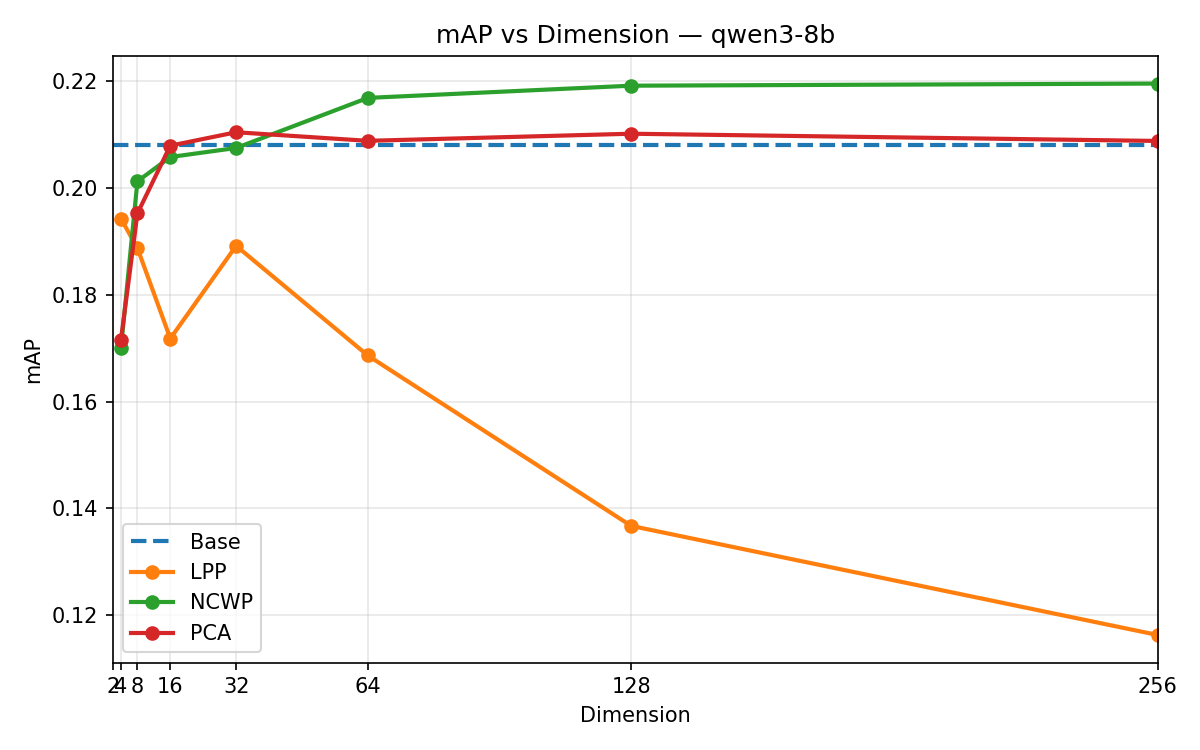

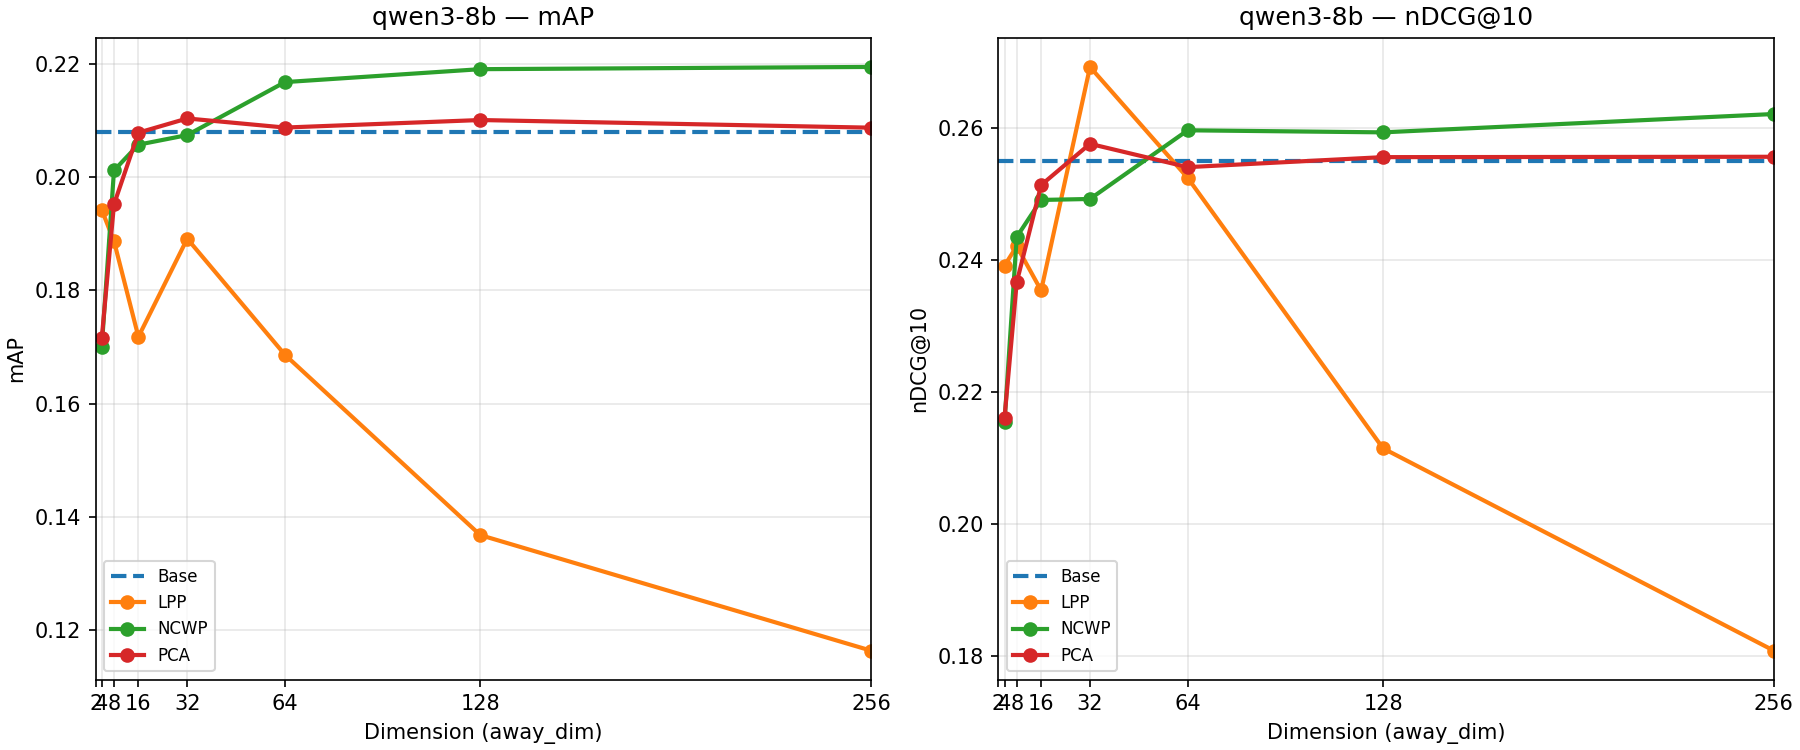

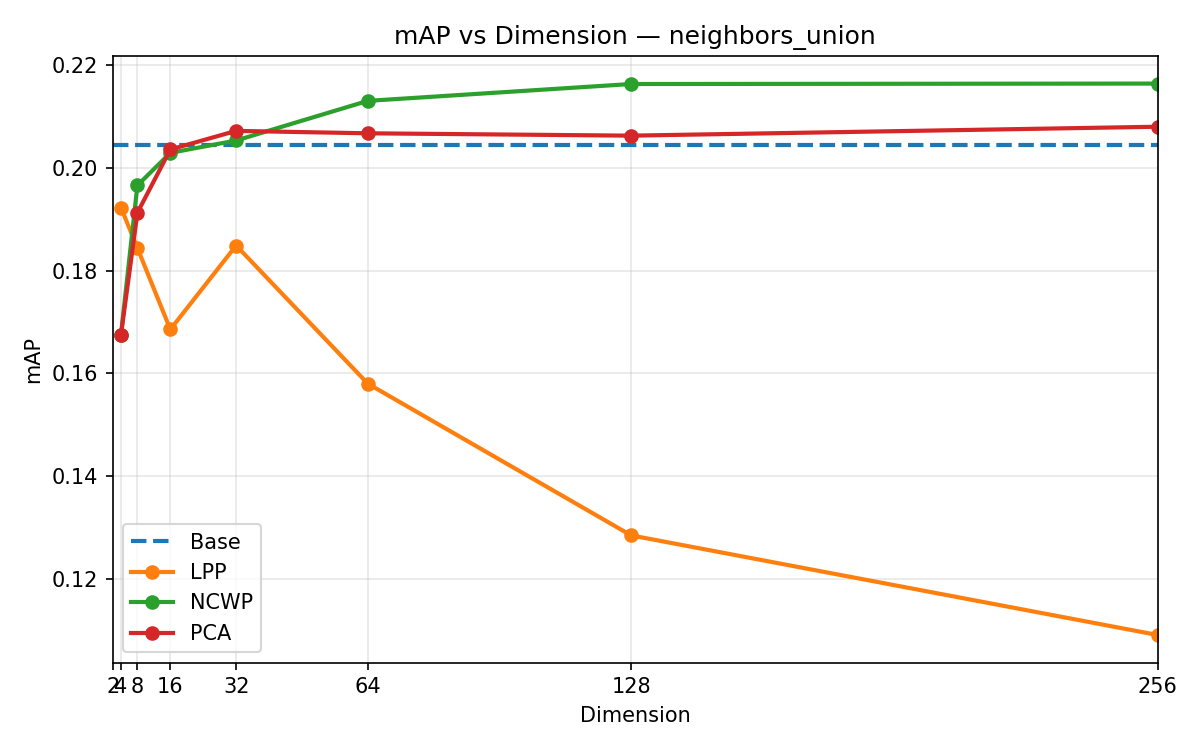

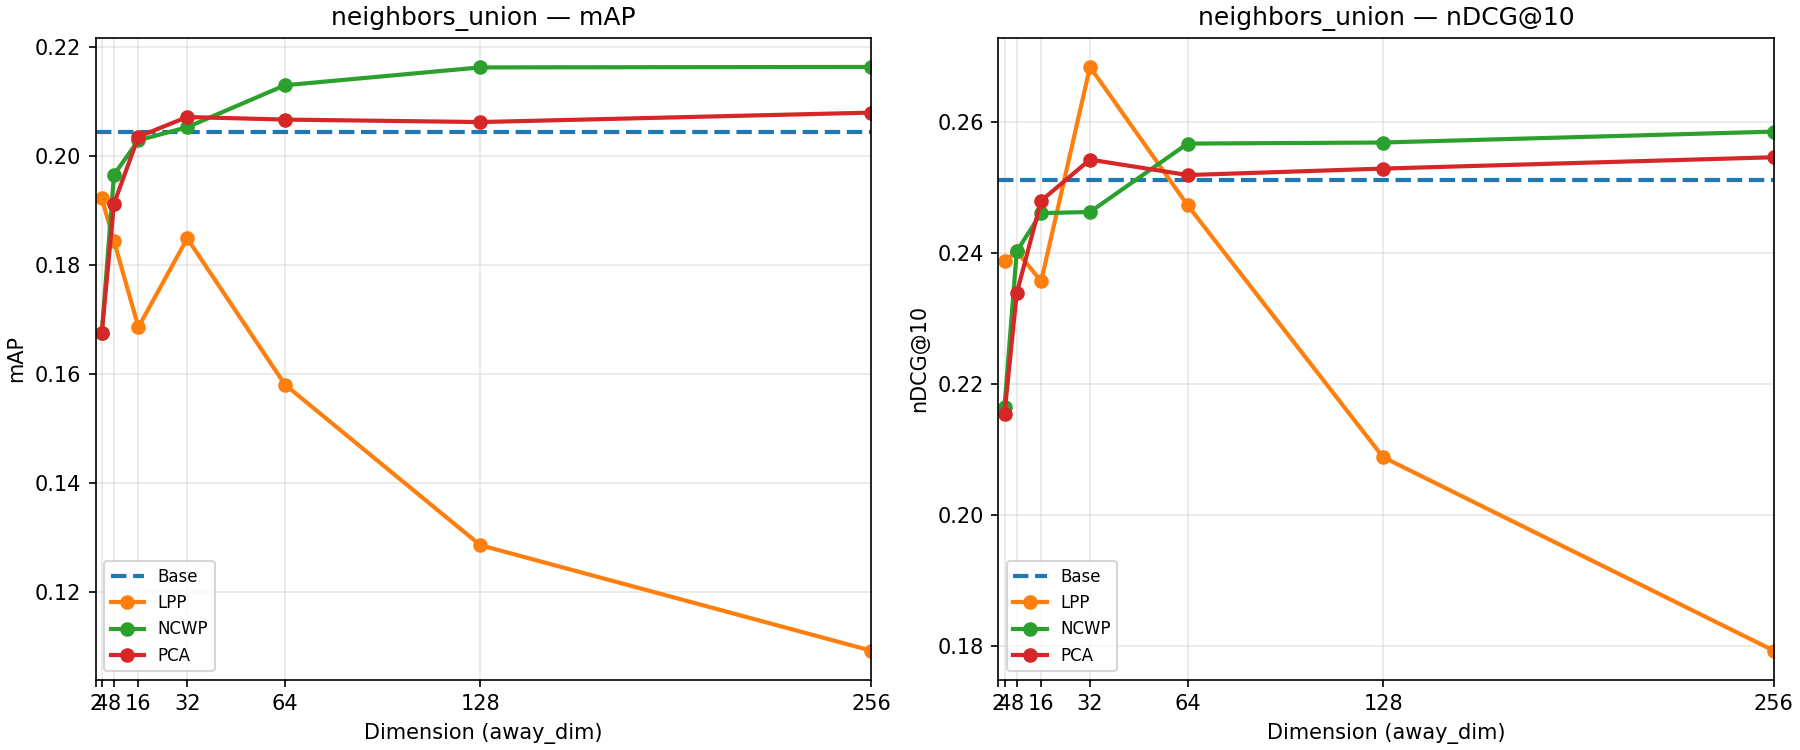

In [7]:
# Display per-tokenizer overview plot and per-label plots
from IPython.display import Image, display

for tok in TOKS:
    print(f"[Display] tok={tok}")
    base_dir = os.path.join(OUT_DIR, tok)

    # Overview plot (all labels together)
    overview_path = os.path.join(base_dir, "map_vs_dim.png")
    if os.path.exists(overview_path):
        display(Image(overview_path))

    # Per-label plots
    df_tok = dfs.get(tok)
    if df_tok is None:
        continue
    labels = [c for c in [
        "nvidia/llama-embed-nemotron-8b", "qwen3-4b", "qwen3-8b", "neighbors_union"
    ] if f"{c}_mAP" in df_tok.columns]
    print("Labels:", labels)

    for lab in labels:
        safe = lab.replace("/", "_")
        map_path = os.path.join(base_dir, f"map_vs_dim_{safe}.png")
        panel_path = os.path.join(base_dir, f"metrics_panels_{safe}.png")
        if os.path.exists(map_path):
            display(Image(map_path))
        if os.path.exists(panel_path):
            display(Image(panel_path))
